In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import geopandas as gpd 
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch

In [30]:
nonval_df = pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_non_validated_v8.xlsx")
validated_df = pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_validated_v8.xlsx")

In [31]:
validated_df['sample_size'] = validated_df['sample_size'].replace('-', np.nan)


In [32]:
validated_df['sample_size'] = pd.to_numeric(validated_df['sample_size'], errors='coerce')

In [33]:
validated_df["pmid"].nunique()

126

In [34]:
validated_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [35]:
df_2022=validated_df[validated_df["year_pub"]==2022].loc[:,["pmid", "town", 'country', "raw_count", 'k13_validated_mutations', 'percentage_frequency']].dropna()
df_2022

,pmid,town,country,raw_count,k13_validated_mutations,percentage_frequency
10,35703955,Kinshasa,DRC,0,-,0
11,36036611,Siaya,Kenya,0,-,0
19,36451216,Pawe,Ethiopia,0,-,0
20,36451216,Gamu-Gofa,Ethiopia,0,-,0
505,36289202,Agago,Uganda,18,C469Y,34
506,36289202,Agago,Uganda,7,A675V,13
508,36289202,"Tororo, Busiu, Masafu",Uganda,1,C469Y,3
509,36289202,"Tororo, Busiu, Masafu",Uganda,1,A675V,3
919,34216470,missing,Rwanda,16,R561H,21.9
920,34216470,missing,Rwanda,1,P574L,1.4


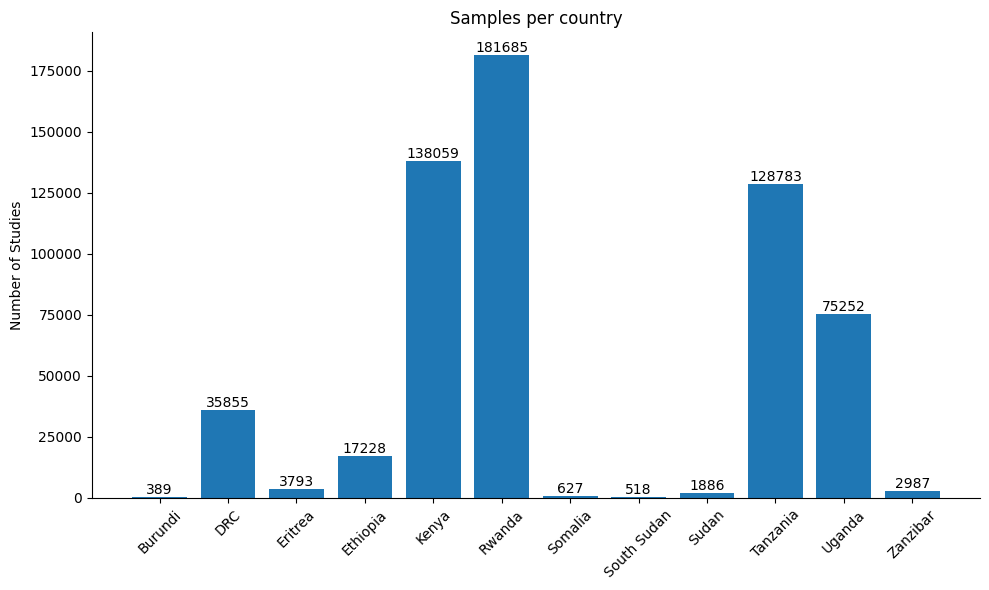

In [36]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country = validated_df.groupby("country")["sample_size"].sum()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["sample_size"],)

for bar in bars:
    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Samples per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/final/paper_report.png", dpi=720, bbox_inches='tight')
plt.show()

In [38]:
# Group by 'pmid' and 'country'
grouped = validated_df.groupby(['pmid', 'country'])

# Sum and count
sample_sum = grouped['sample_size'].sum()
sample_count = grouped['sample_size'].count()

# Compute average
average_sample_size = sample_sum / sample_count

# Reset index to get a DataFrame
average_sample_df = average_sample_size.reset_index(name='average_sample_size')
average_sample_df.head(50)

# Round off to nearest whole number
average_sample_df['average_sample_size'] = average_sample_df['average_sample_size'].astype(float)


In [39]:
# Step 1: Group by 'pmid' and 'country'
grouped = validated_df.groupby(['pmid', 'country'])

# Step 2: Compute average sample size (rounded)
sample_sum = grouped['sample_size'].sum()
sample_count = grouped['sample_size'].count()
average_sample_size = (sample_sum / sample_count).round(0).astype(float)

# Step 3: Get unique year_pub per group (assumes it's the same for all rows in group)
year_pub = grouped['year_pub'].first()  # Or use .min(), .max(), or .mode().iloc[0]

# Step 4: Combine into single DataFrame
result = pd.concat([average_sample_size, year_pub], axis=1).reset_index()
#result.rename(columns={'sample_size': 'average_sample_size'}, inplace=True)
result

,pmid,country,sample_size,year_pub
0,26875763,Eritrea,200.0,2016
1,38377612,DRC,292.0,2024
2,39367758,DRC,927.0,2024
3,39367758,Rwanda,2709.0,2024
4,39367758,Tanzania,1692.0,2024
...,...,...,...,...
144,39136465,Uganda,142.0,2024
145,39136468,Uganda,1112.0,2024
146,39159629,Tanzania,599.0,2024
147,39159633,Tanzania,176.0,2024


In [40]:
result["pmid"].nunique()

126

In [41]:
total_country= result.pivot_table(
    index="country",
    values="sample_size",
    aggfunc="sum"
)
total_country

,sample_size
country,
Burundi,389.0
DRC,17594.0
Eritrea,1237.0
Ethiopia,3472.0
Kenya,14560.0
Rwanda,10615.0
Somalia,627.0
South Sudan,518.0
Sudan,437.0


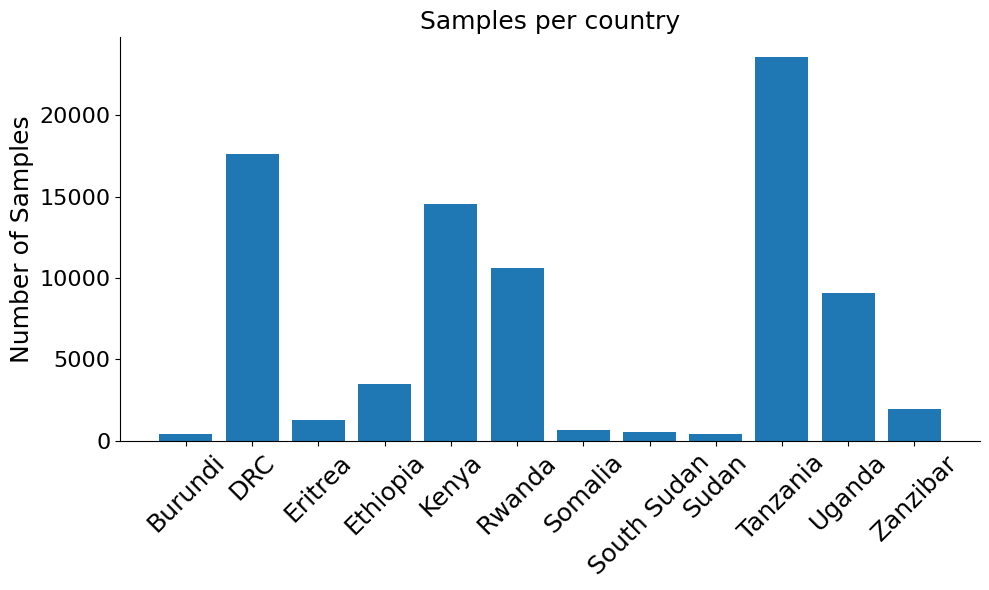

In [42]:
# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(total_country.index, total_country["sample_size"],)

#for bar in bars:
#    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
#    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Samples", fontsize=18)
plt.title("Samples per country", fontsize=18)

# Show plot
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("../results/final/paper_report.png", dpi=720, bbox_inches='tight')
plt.show()

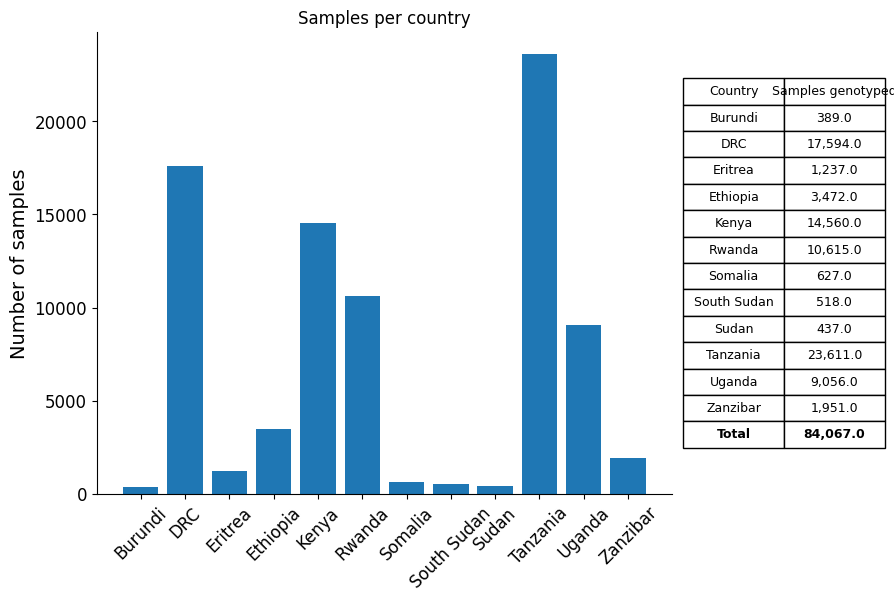

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Sort data if needed (optional) ----
# total_country_sorted = total_country.sort_values("sample_size", ascending=True)
# Using original order here

fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
bars = ax.bar(total_country.index, total_country["sample_size"])

sns.despine(top=True, right=True)

# Labels and title
ax.set_ylabel("Number of samples", size=14)
ax.set_title("Samples per country")

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=12)

# ---- Compute total ----
total_samples = total_country["sample_size"].sum()

# ---- Create table data ----
table_data = [
    [country, f"{samples:,}"]
    for country, samples in zip(total_country.index, total_country["sample_size"])
]

# Add total row
table_data.append(["Total", f"{total_samples:,}"])

# ---- Add table outside axes ----
table = ax.table(
    cellText=table_data,
    colLabels=["Country", "Samples genotyped"],
    cellLoc='center',
    colLoc='center',
    bbox=[1.02, 0.1, 0.35, 0.8]  # Pushed outside right of plot
)

# Styling table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.1)

# ---- Make total row bold ----
last_row_index = len(table_data)
for col in range(2):
    table[(last_row_index, col)].set_text_props(weight='bold')

# ---- Adjust layout to make room for table ----
plt.subplots_adjust(right=0.7)

# Save
plt.savefig("../results/final/paper_report1.png", dpi=720, bbox_inches='tight')

plt.show()

In [44]:
pivot_table = result.pivot_table(
    index="country",
    columns="year_pub",
    values="sample_size",
    aggfunc="sum",    # Aggregate multiple values per country/year
    fill_value=0
).astype(int)
pivot_table

year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country,,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,389,0,0,0,0
DRC,128,0,0,580,1622,0,1070,1684,2504,0,3211,6795
Eritrea,0,0,200,0,0,0,144,41,0,852,0,0
Ethiopia,82,301,0,226,0,413,0,0,379,333,649,1089
Kenya,160,868,136,287,72,144,551,682,4178,3442,526,3514
Rwanda,0,0,85,0,0,0,954,1068,186,2146,5630,546
Somalia,0,0,0,0,0,339,0,138,0,150,0,0
South Sudan,0,0,0,0,0,0,0,0,0,518,0,0
Sudan,0,0,0,0,0,31,186,0,0,92,0,128


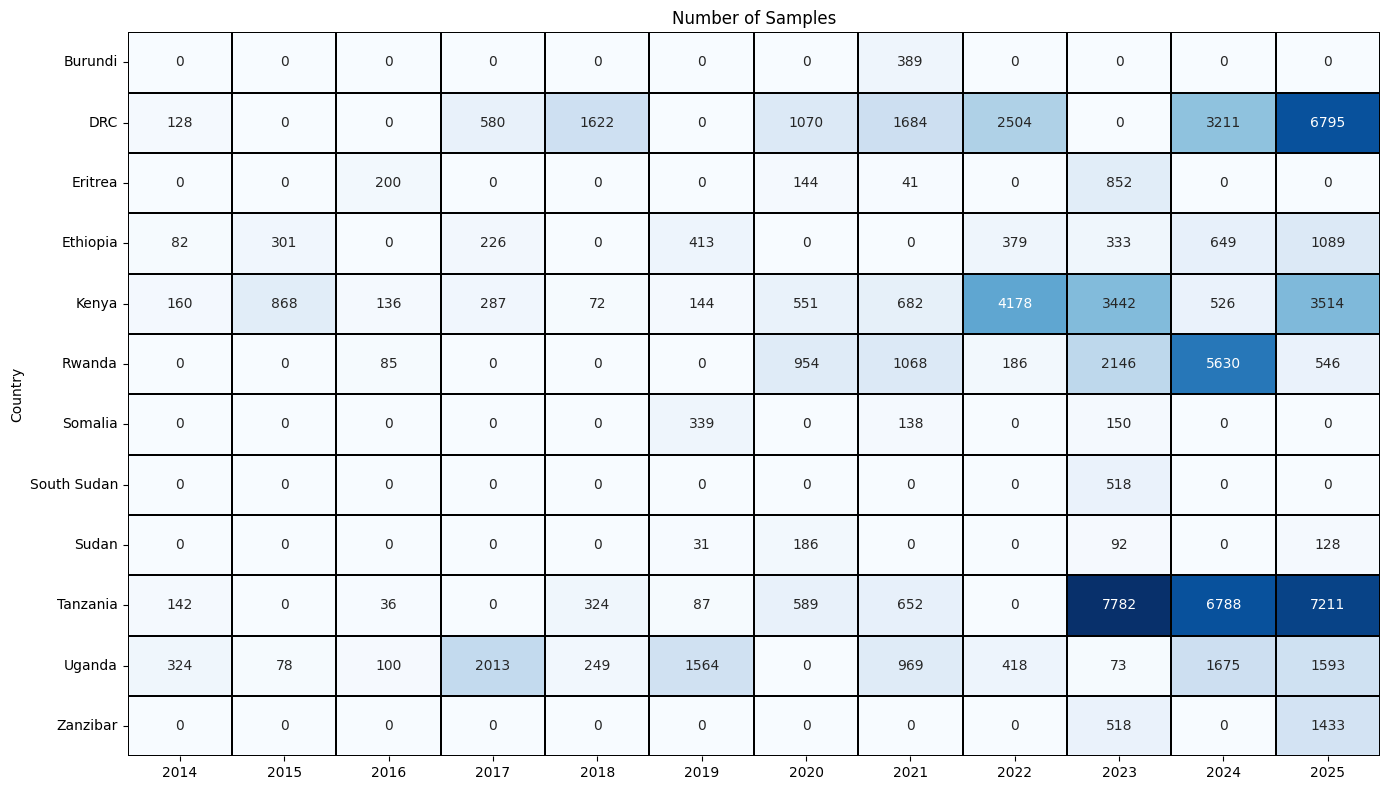

In [16]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt="d",              # Display as integers
    cmap="Blues",         # Monochrome grayscale
    cbar=False,           # Hide the color bar
    linewidths=0.05,       # Optional: thin borders between cells
    linecolor='black' # Optional: border color
)

plt.title("Number of Samples")
plt.xlabel("")            # Optional: hide x-axis label
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("../results/final/heatmap.png", dpi=300)
plt.show()

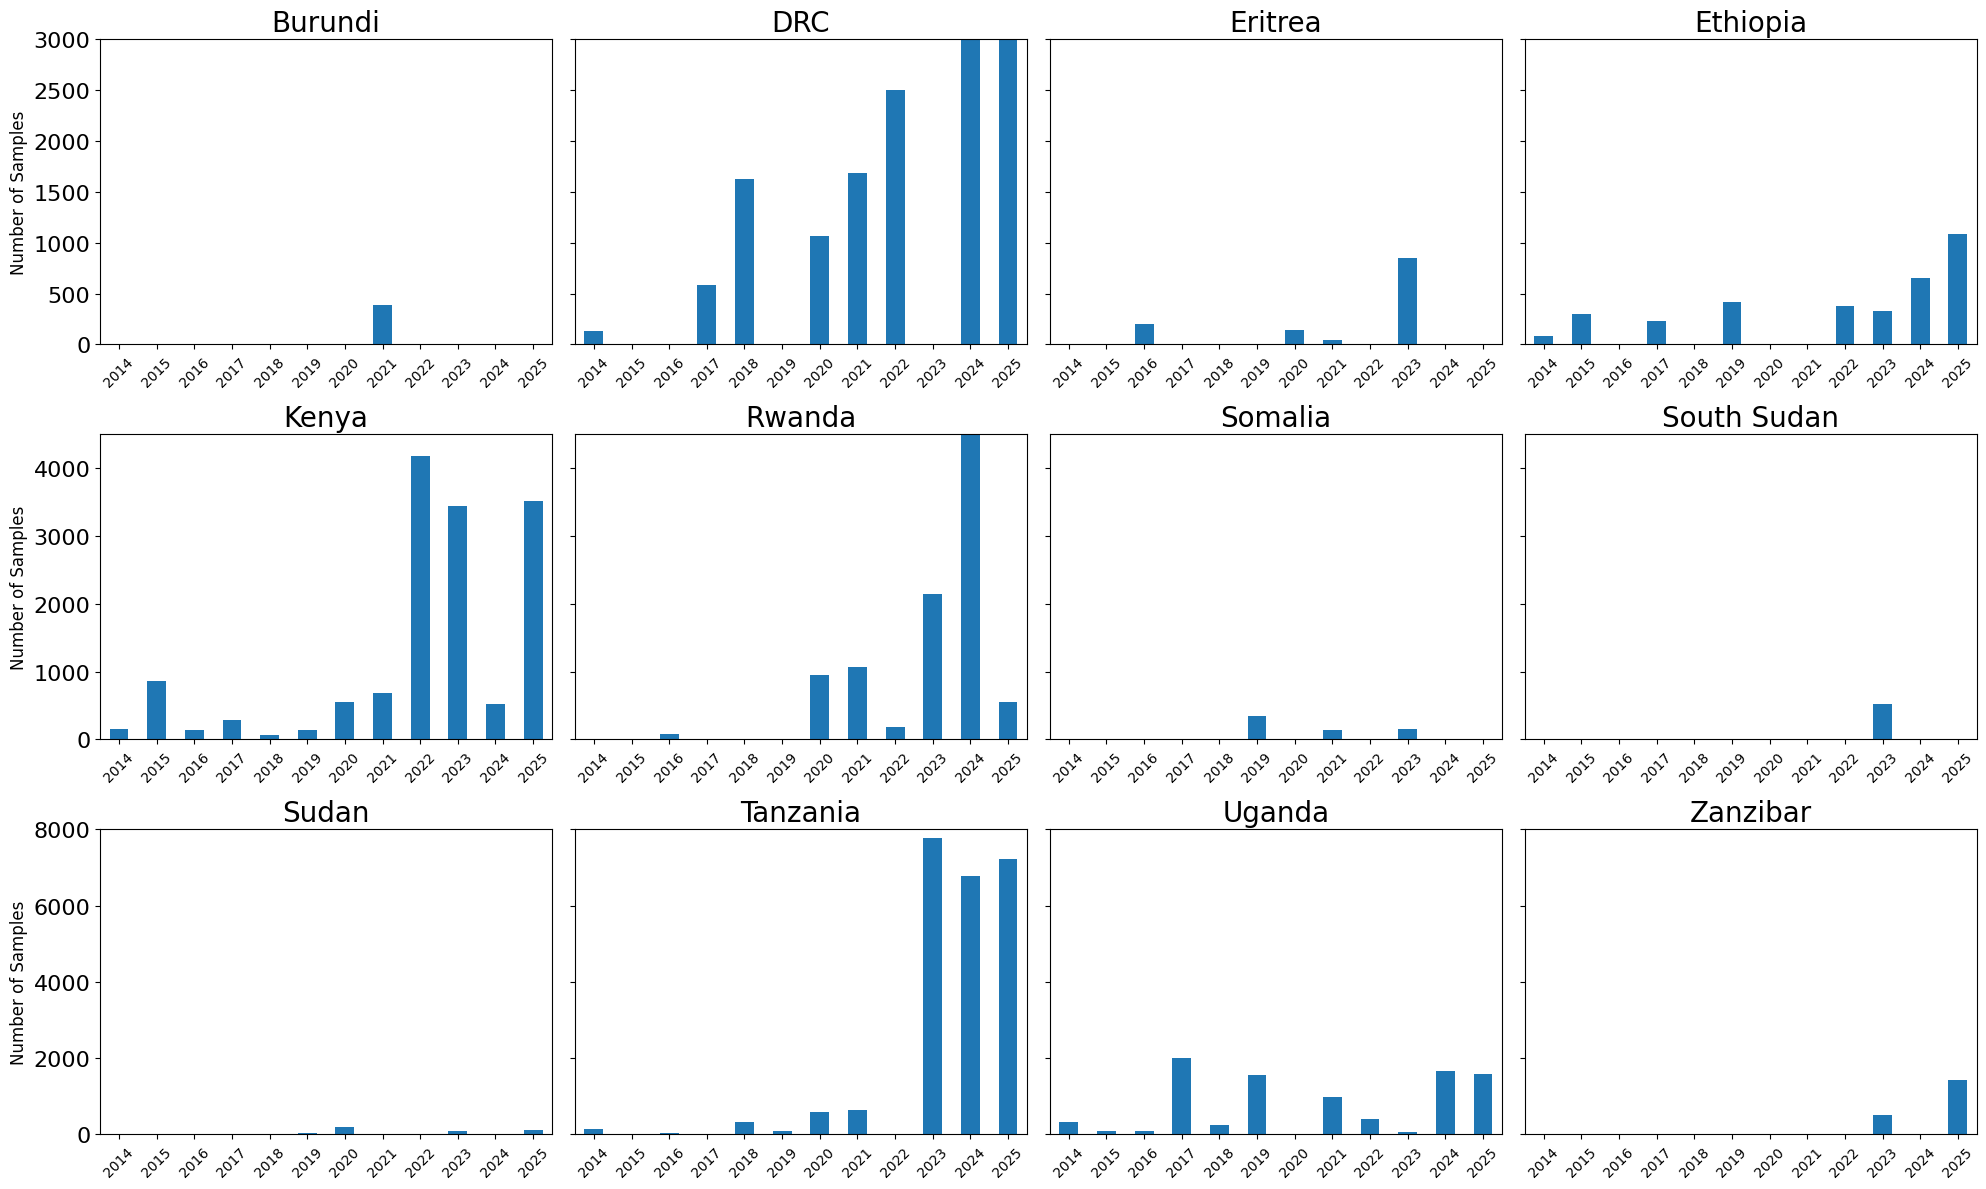

In [17]:
# Set number of countries and layout for subplots
countries = pivot_table.index.tolist()
n_countries = len(countries)

# Determine subplot grid size (e.g., 4 columns)
ncols = 4
nrows = -(-n_countries // ncols)  # Ceiling division

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharey=False)
axes = axes.flatten()  # Flatten in case it's 2D

# Define y-axis limits per row
y_limits_by_row = {
    0: 3000,  # First row
    1: 4500,  # Second row
    2: 8000   # Third row, if it exists
    # Add more rows if needed
}

# Plot each country's data
for i, country in enumerate(countries):
    ax = axes[i]
    pivot_table.loc[country].plot(kind="bar", ax=ax)
    title = country.upper() if country.lower() == "drc" else country.title()
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=16)

    # Set y-axis limit based on row number
    row_idx = i // ncols
    if row_idx in y_limits_by_row:
        ax.set_ylim(0, y_limits_by_row[row_idx])

    # Show x and y labels only for the first subplot in each row
    if i % ncols == 0:
        ax.set_ylabel("Number of Samples", fontsize=12)
        ax.set_xlabel("")  # Leave as is, or add a label if needed
    else:
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(labelleft=False)  # Hide y-axis tick labels

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.suptitle("Number of Papers Published Per Year by Country", fontsize=16, y=1.02)
plt.savefig("../results/final/samples_per_country.png", dpi=720)
plt.savefig("../results/final/samples_per_country.pdf")
plt.show()

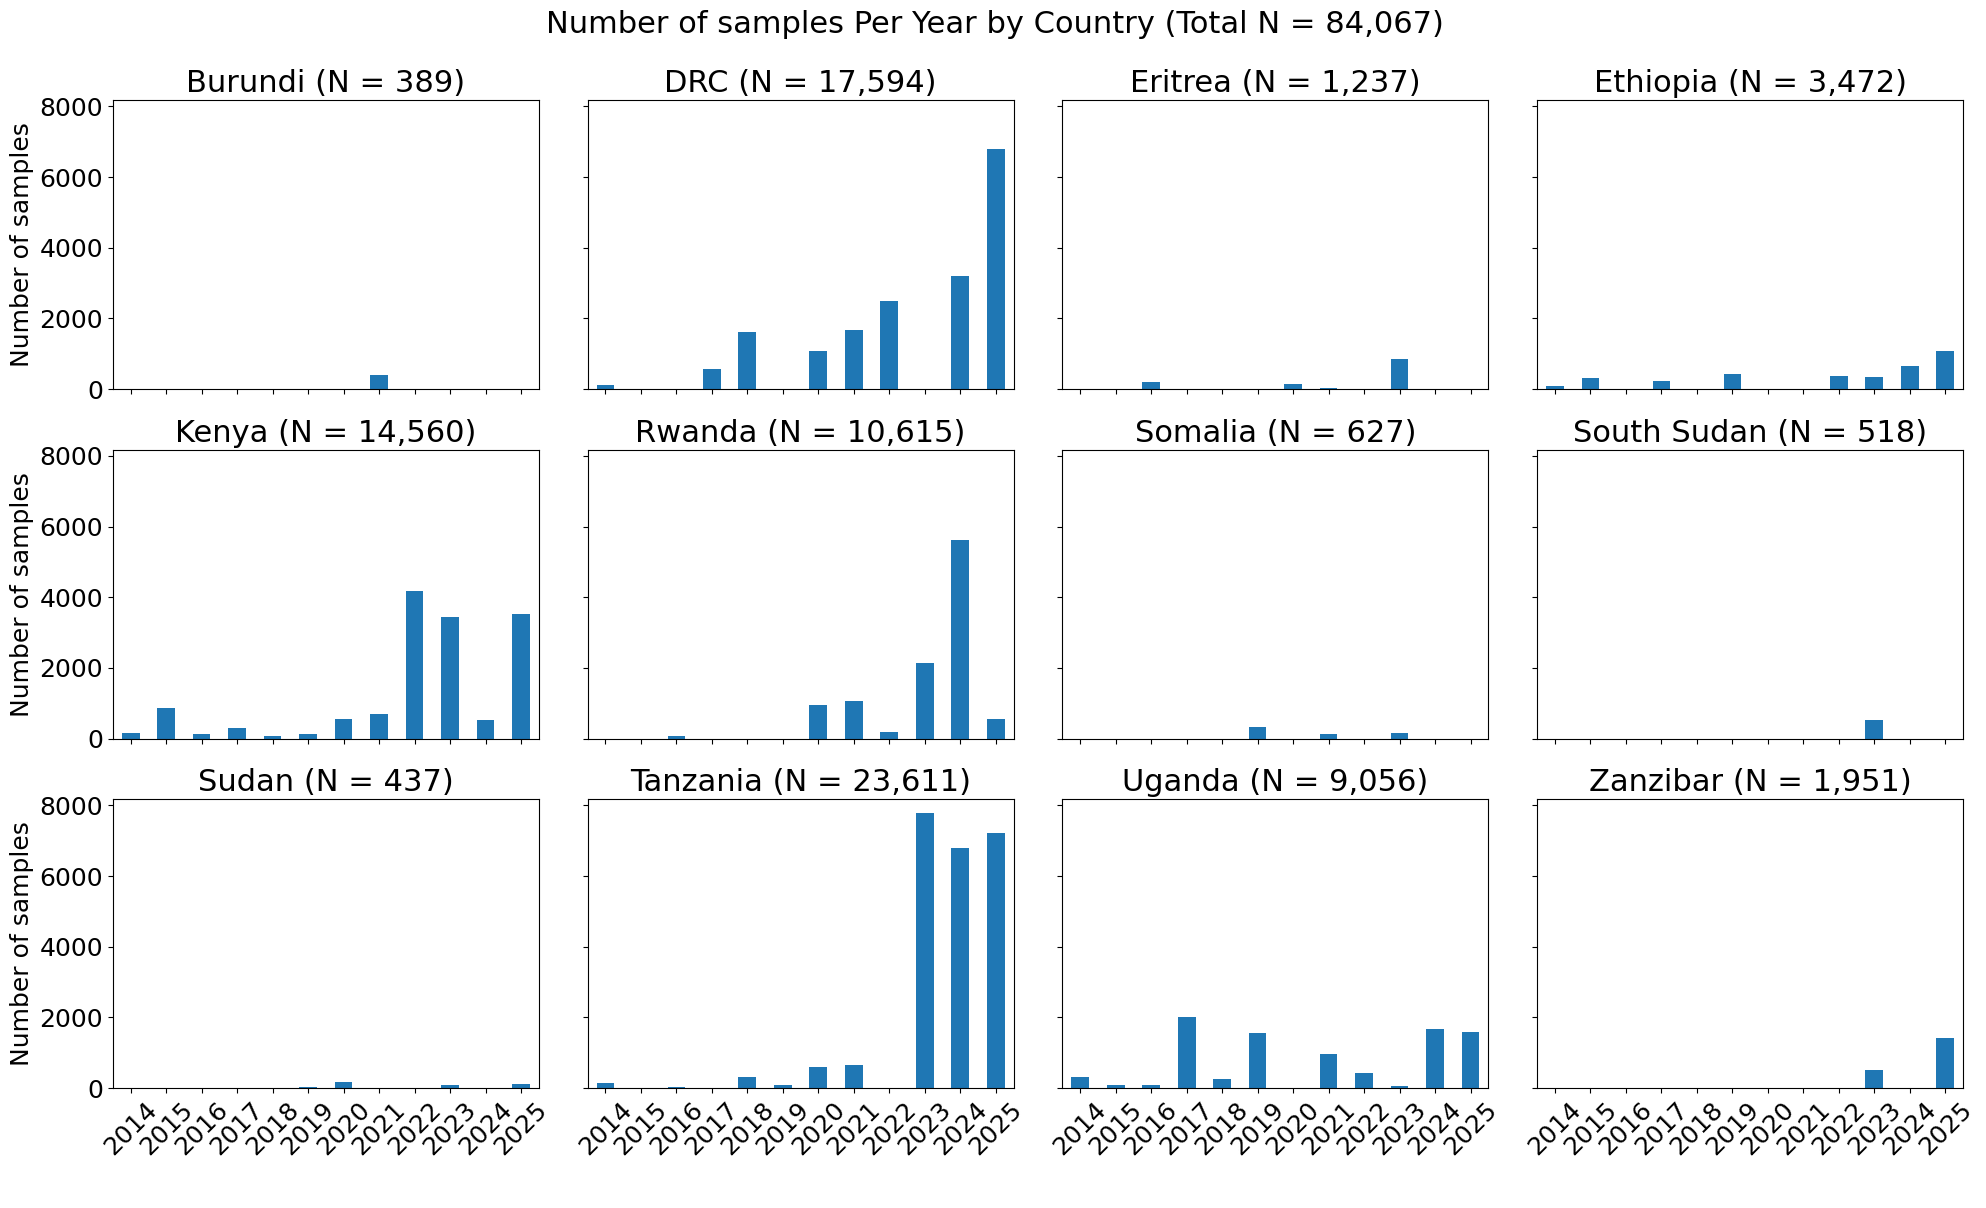

In [18]:
# =======================
# 2. SUBPLOTS: Papers per year by country (WITH N)
# =======================

# Countries
countries = pivot_table.index.tolist()
n_countries = len(countries)

# Layout
ncols = 4
nrows = -(-n_countries // ncols)  # Ceiling division

# Totals per country (IMPORTANT)
country_totals = pivot_table.sum(axis=1)
grand_total = country_totals.sum()

# Create subplots
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 5, nrows * 4),
    sharey=True,
    sharex=True   # ✅ share x-axis
)

axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]

    pivot_table.loc[country].plot(kind="bar", ax=ax)

    N = country_totals[country]
    title = country.upper() if country.lower() == "drc" else country.title()

    ax.set_title(f"{title} (N = {N:,})", fontsize=22)
    ax.set_ylabel("Number of samples", fontsize=18)

    # ✅ Only show x labels on bottom row
    if i < (nrows - 1) * ncols:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=18)
        ax.set_xlabel('')
        '''for label in ax.get_xticklabels():
            label.set_fontweight('bold') '''

    ax.tick_params(axis="y", labelsize=18)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Global labels
fig.supxlabel(" ", fontsize=16)  # ✅ one shared x label

plt.suptitle(
    f"Number of samples Per Year by Country (Total N = {grand_total:,})",
    fontsize=22,
    y=1
)

plt.tight_layout()
plt.savefig("../results/final/samples_per_country_std.png", dpi=300)
plt.show()

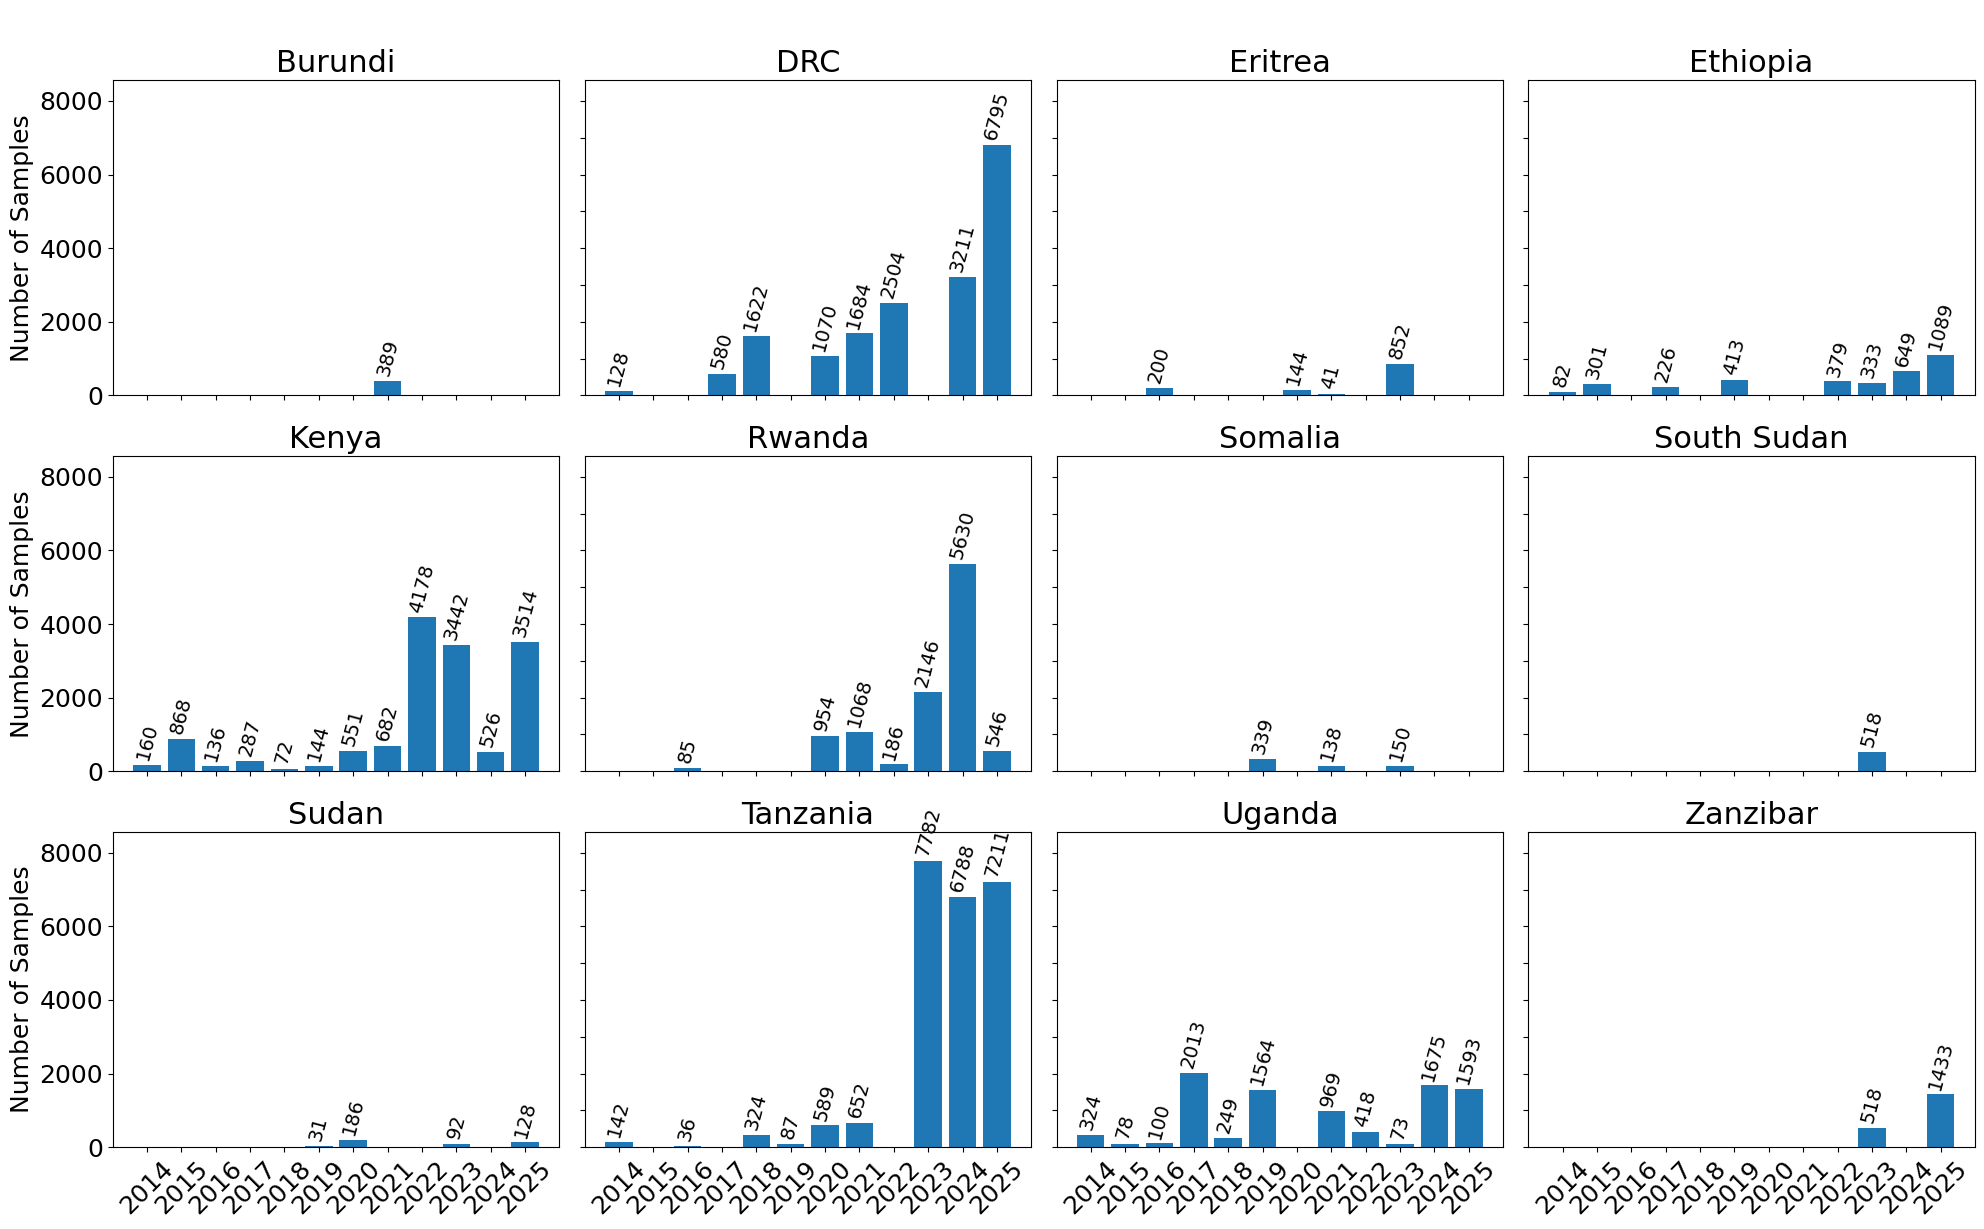

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

countries = pivot_table.index.tolist()
n_countries = len(countries)

# Layout
ncols = 4
nrows = -(-n_countries // ncols)  # ceiling division

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(ncols * 5, nrows * 4),
    sharex=True
)
axes = axes.flatten()

x_labels = pivot_table.columns.tolist()
x = range(len(x_labels))
y_max = pivot_table.max().max()
y_lim = (0, y_max + y_max*0.1)

for i, country in enumerate(countries):
    ax = axes[i]
    y = pivot_table.loc[country].values

    bars = ax.bar(x, y)
    ax.set_ylim(y_lim)

    # Titles
    title = country.upper() if country.lower() == "drc" else country.title()
    ax.set_title(title, fontsize=22)

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, fontsize=18)

    # Remove individual y-axis labels for all but first subplot in row
    row_idx = i // ncols
    col_idx = i % ncols
    if col_idx != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel("Number of Samples", fontsize=18)
        ax.tick_params(axis='y', labelsize=18) 

    # Value labels
    for p in bars:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + y_max*0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=14,
                rotation=75
            )

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(" ", fontsize=16, y=1.02)
plt.savefig("../results/final/samples_per_country_numbered.png", dpi=300)
#plt.savefig("../results/final/samples_per_country_numbered.pdf")
plt.show()

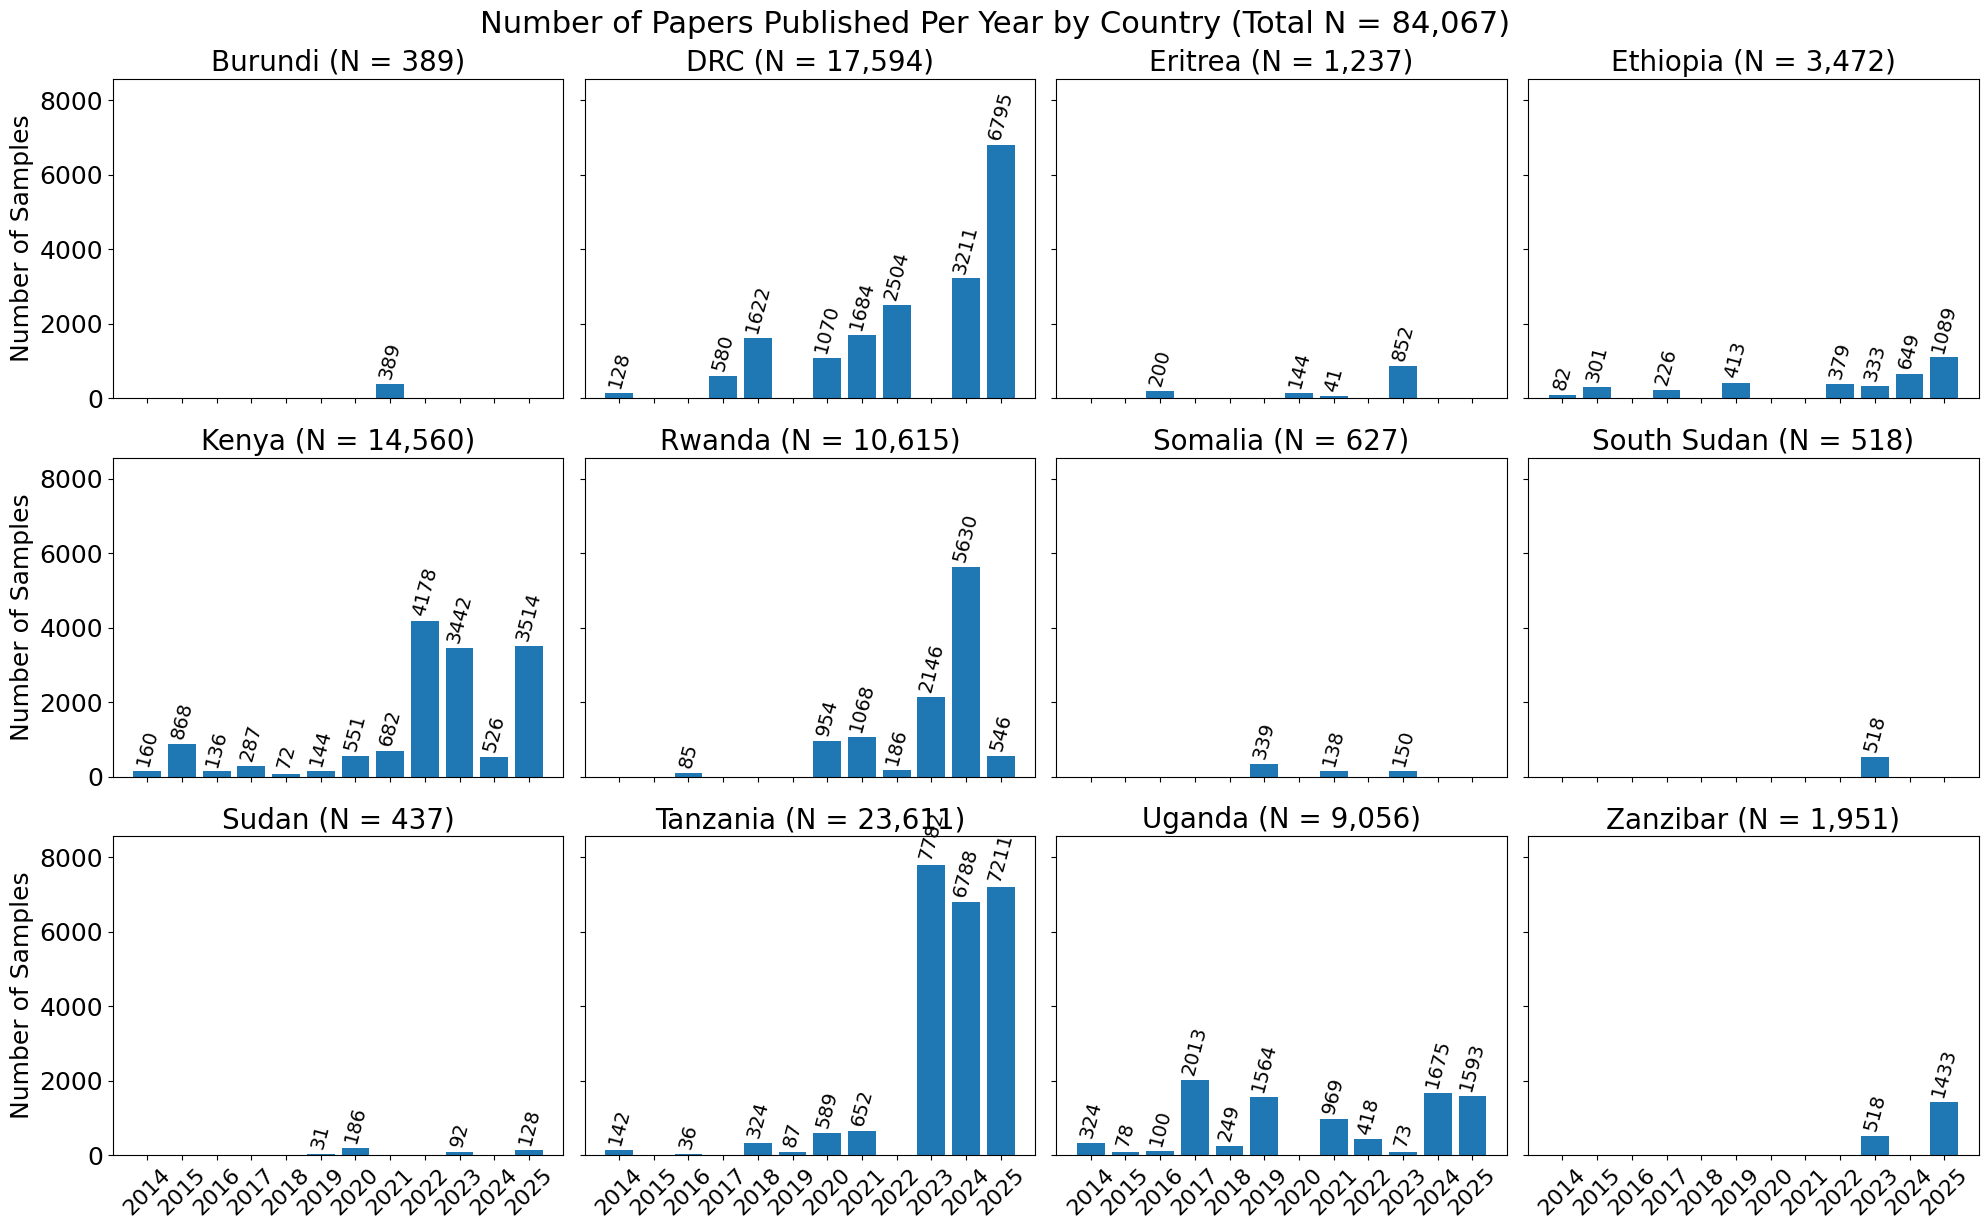

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

countries = pivot_table.index.tolist()
n_countries = len(countries)
ncols = 4
nrows = -(-n_countries // ncols)  # ceiling division

# Totals
country_totals = pivot_table.sum(axis=1)
grand_total = country_totals.sum()

# Create subplots with shared x and y axes
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 5, nrows * 4),
    sharex=True, sharey=True
)
axes = axes.flatten()

x_labels = pivot_table.columns.tolist()
x = range(len(x_labels))
y_max = pivot_table.max().max()
y_lim = (0, y_max + y_max * 0.1)

for i, country in enumerate(countries):
    ax = axes[i]
    y = pivot_table.loc[country].values

    # Bar plot manually for consistent axes
    bars = ax.bar(x, y)
    ax.set_ylim(y_lim)

    # Title with N
    title = country.upper() if country.lower() == "drc" else country.title()
    N = country_totals[country]
    ax.set_title(f"{title} (N = {N:,})", fontsize=20)

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, fontsize=16)

    # Y-axis: only leftmost subplot in row shows label
    col_idx = i % ncols
    if col_idx == 0:
        ax.set_ylabel("Number of Samples", fontsize=18)
        ax.tick_params(axis='y', labelsize=18)
    else:
        ax.tick_params(axis='y', labelsize=0)  # hide y-tick labels

    # Value labels
    for p in bars:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + y_max * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=14,
                rotation=75
            )

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(
    f"Number of Papers Published Per Year by Country (Total N = {grand_total:,})",
    fontsize=22, y=1.02
)

# Save figures
plt.savefig("../results/final/samples_per_country_numbered1.png", dpi=300)
plt.show()

In [21]:
pivot_table

year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country,,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,389,0,0,0,0
DRC,128,0,0,580,1622,0,1070,1684,2504,0,3211,6795
Eritrea,0,0,200,0,0,0,144,41,0,852,0,0
Ethiopia,82,301,0,226,0,413,0,0,379,333,649,1089
Kenya,160,868,136,287,72,144,551,682,4178,3442,526,3514
Rwanda,0,0,85,0,0,0,954,1068,186,2146,5630,546
Somalia,0,0,0,0,0,339,0,138,0,150,0,0
South Sudan,0,0,0,0,0,0,0,0,0,518,0,0
Sudan,0,0,0,0,0,31,186,0,0,92,0,128


In [22]:
import pandas as pd

# ---- Functions ----
def format_cell(x, N):
    if x == 0:
        return "0"
    pct = x / N * 100
    if pct == 100:
        return f"{x} (100%)"
    else:
        return f"{x} ({pct:.2f}%)"

def format_overall(x, grand_total):
    if x == 0:
        return "0"
    pct = x / grand_total * 100
    if pct == 100:
        return f"{x} (100%)"
    else:
        return f"{x} ({pct:.2f}%)"

# ---- Current pivot table: rows = countries, columns = year_pub ----
# Example: pivot_table = your DataFrame with country index and year_pub columns

# 1️⃣ Compute row totals per country
country_totals = pivot_table.sum(axis=1)

# 2️⃣ Compute grand total (all counts)
grand_total = country_totals.sum()

# 3️⃣ Format cells per country (percentage of that country’s total)
formatted_table = pivot_table.copy()
for country in pivot_table.index:
    N = country_totals[country]
    formatted_table.loc[country] = pivot_table.loc[country].apply(lambda x: format_cell(x, N))

# 4️⃣ Add Overall column (sum per country with percentage of grand total)
formatted_table['Overall'] = pivot_table.sum(axis=1).apply(lambda x: format_overall(x, grand_total))

# 5️⃣ Optionally reorder columns → Overall first
cols = ['Overall'] + [c for c in pivot_table.columns if c != 'Overall']
formatted_table = formatted_table[cols]

# 6️⃣ Create stacked headers with N per country (sum of each row)
new_columns = []
for col in formatted_table.columns:
    if col == 'Overall':
        new_columns.append(('Overall', f'N = {grand_total:,}'))
    else:
        # Column total is the sum across countries for that year
        year_total = pivot_table[col].sum()
        new_columns.append((col, f'N = {year_total:,}'))

formatted_table.columns = pd.MultiIndex.from_tuples(new_columns)

formatted_table

/tmp/ipykernel_20055/258186779.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  formatted_table.loc[country] = pivot_table.loc[country].apply(lambda x: format_cell(x, N))
/tmp/ipykernel_20055/258186779.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  formatted_table.loc[country] = pivot_table.loc[country].apply(lambda x: format_cell(x, N))
/tmp/ipykernel_20055/258186779.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  formatted_table.loc[country] = pivot_tabl

,Overall,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
,"N = 84,067",N = 836,"N = 1,247",N = 557,"N = 3,106","N = 2,267","N = 2,578","N = 3,494","N = 5,623","N = 7,665","N = 15,906","N = 18,479","N = 22,309"
country,,,,,,,,,,,,,
Burundi,389 (0.46%),0,0,0,0,0,0,0,389 (100%),0,0,0,0
DRC,17594 (20.93%),128 (0.73%),0,0,580 (3.30%),1622 (9.22%),0,1070 (6.08%),1684 (9.57%),2504 (14.23%),0,3211 (18.25%),6795 (38.62%)
Eritrea,1237 (1.47%),0,0,200 (16.17%),0,0,0,144 (11.64%),41 (3.31%),0,852 (68.88%),0,0
Ethiopia,3472 (4.13%),82 (2.36%),301 (8.67%),0,226 (6.51%),0,413 (11.90%),0,0,379 (10.92%),333 (9.59%),649 (18.69%),1089 (31.37%)
Kenya,14560 (17.32%),160 (1.10%),868 (5.96%),136 (0.93%),287 (1.97%),72 (0.49%),144 (0.99%),551 (3.78%),682 (4.68%),4178 (28.70%),3442 (23.64%),526 (3.61%),3514 (24.13%)
Rwanda,10615 (12.63%),0,0,85 (0.80%),0,0,0,954 (8.99%),1068 (10.06%),186 (1.75%),2146 (20.22%),5630 (53.04%),546 (5.14%)
Somalia,627 (0.75%),0,0,0,0,0,339 (54.07%),0,138 (22.01%),0,150 (23.92%),0,0
South Sudan,518 (0.62%),0,0,0,0,0,0,0,0,0,518 (100%),0,0


In [23]:
# ---- Make a copy and convert to object type ----
formatted_table = pivot_table.copy().astype(object)

# ---- Format each country row ----
for country in pivot_table.index:
    N = pivot_table.loc[country].sum()  # total for that country
    formatted_table.loc[country] = pivot_table.loc[country].apply(lambda x: format_cell(x, N))

# ---- Add Overall column (sum per country with % of grand total) ----
grand_total = pivot_table.values.sum()
formatted_table['Overall'] = pivot_table.sum(axis=1).apply(lambda x: format_overall(x, grand_total))

# ---- Optional: reorder columns → Overall first ----
cols = ['Overall'] + [c for c in pivot_table.columns if c != 'Overall']
formatted_table = formatted_table[cols]

# ---- Create stacked headers ----
country_totals = pivot_table.sum(axis=1)  # sum per country
new_columns = []
for col in formatted_table.columns:
    if col == 'Overall':
        new_columns.append(('Overall', f'N = {grand_total:,}'))
    else:
        year_total = pivot_table[col].sum()
        new_columns.append((col, f'N = {year_total:,}'))

formatted_table.columns = pd.MultiIndex.from_tuples(new_columns)

formatted_table

,Overall,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
,"N = 84,067",N = 836,"N = 1,247",N = 557,"N = 3,106","N = 2,267","N = 2,578","N = 3,494","N = 5,623","N = 7,665","N = 15,906","N = 18,479","N = 22,309"
country,,,,,,,,,,,,,
Burundi,389 (0.46%),0,0,0,0,0,0,0,389 (100%),0,0,0,0
DRC,17594 (20.93%),128 (0.73%),0,0,580 (3.30%),1622 (9.22%),0,1070 (6.08%),1684 (9.57%),2504 (14.23%),0,3211 (18.25%),6795 (38.62%)
Eritrea,1237 (1.47%),0,0,200 (16.17%),0,0,0,144 (11.64%),41 (3.31%),0,852 (68.88%),0,0
Ethiopia,3472 (4.13%),82 (2.36%),301 (8.67%),0,226 (6.51%),0,413 (11.90%),0,0,379 (10.92%),333 (9.59%),649 (18.69%),1089 (31.37%)
Kenya,14560 (17.32%),160 (1.10%),868 (5.96%),136 (0.93%),287 (1.97%),72 (0.49%),144 (0.99%),551 (3.78%),682 (4.68%),4178 (28.70%),3442 (23.64%),526 (3.61%),3514 (24.13%)
Rwanda,10615 (12.63%),0,0,85 (0.80%),0,0,0,954 (8.99%),1068 (10.06%),186 (1.75%),2146 (20.22%),5630 (53.04%),546 (5.14%)
Somalia,627 (0.75%),0,0,0,0,0,339 (54.07%),0,138 (22.01%),0,150 (23.92%),0,0
South Sudan,518 (0.62%),0,0,0,0,0,0,0,0,0,518 (100%),0,0


In [24]:
import pandas as pd
import dataframe_image as dfi

# ---- 1️⃣ Ensure formatted_table is object type ----
formatted_table = formatted_table.astype(object)

# ---- 2️⃣ Apply styling for stacked headers ----
styled = formatted_table.style.set_table_styles([
    # Top-level headers (Overall / years)
    {'selector': 'th.col_heading.level0',
     'props': [('padding-bottom', '0px')]},

    # Bottom-level headers (N = total per year / Overall)
    {'selector': 'th.col_heading.level1',
     'props': [
         ('padding-top', '0px'),
         ('font-size', '9pt')  # slightly smaller looks cleaner
     ]}
])

# ---- 3️⃣ Export as high-resolution PNG ----
dfi.export(
    styled,                  # ← your styled table
    "../results/final/samples_per_country_years.png",
    table_conversion="matplotlib",
    fontsize=16,             # controls overall table height
    dpi=720                  # high resolution
)
styled

/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.0.1)/charset_normalizer (3.3.1) doesn't match a supported version!
  warnings.warn(


,Overall,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
,"N = 84,067",N = 836,"N = 1,247",N = 557,"N = 3,106","N = 2,267","N = 2,578","N = 3,494","N = 5,623","N = 7,665","N = 15,906","N = 18,479","N = 22,309"
country,,,,,,,,,,,,,
Burundi,389 (0.46%),0,0,0,0,0,0,0,389 (100%),0,0,0,0
DRC,17594 (20.93%),128 (0.73%),0,0,580 (3.30%),1622 (9.22%),0,1070 (6.08%),1684 (9.57%),2504 (14.23%),0,3211 (18.25%),6795 (38.62%)
Eritrea,1237 (1.47%),0,0,200 (16.17%),0,0,0,144 (11.64%),41 (3.31%),0,852 (68.88%),0,0
Ethiopia,3472 (4.13%),82 (2.36%),301 (8.67%),0,226 (6.51%),0,413 (11.90%),0,0,379 (10.92%),333 (9.59%),649 (18.69%),1089 (31.37%)
Kenya,14560 (17.32%),160 (1.10%),868 (5.96%),136 (0.93%),287 (1.97%),72 (0.49%),144 (0.99%),551 (3.78%),682 (4.68%),4178 (28.70%),3442 (23.64%),526 (3.61%),3514 (24.13%)
Rwanda,10615 (12.63%),0,0,85 (0.80%),0,0,0,954 (8.99%),1068 (10.06%),186 (1.75%),2146 (20.22%),5630 (53.04%),546 (5.14%)
Somalia,627 (0.75%),0,0,0,0,0,339 (54.07%),0,138 (22.01%),0,150 (23.92%),0,0
South Sudan,518 (0.62%),0,0,0,0,0,0,0,0,0,518 (100%),0,0


In [25]:
import pandas as pd
import dataframe_image as dfi

# Ensure object type
formatted_table = formatted_table.astype(object)

# Apply styling
styled = formatted_table.style.set_table_styles([
    # Top-level headers (Overall / years)
    {'selector': 'th.col_heading.level0',
     'props': [
         ('padding-bottom', '0px'),
         ('font-size', '20pt'),   # increase top header font
         ('text-align', 'center'),
         ('font-weight', 'bold')
     ]},

    # Bottom-level headers (N = total per year / Overall)
    {'selector': 'th.col_heading.level1',
     'props': [
         ('padding-top', '0px'),
         ('font-size', '18pt'),   # increase bottom header font
         ('text-align', 'center')
     ]},

    # Data cells
    {'selector': 'td',
     'props': [
         ('font-size', '16pt'),   # increase cell font
         ('text-align', 'center')
     ]}
])

# Export as high-resolution PNG
dfi.export(
    styled,
    "../results/final/samples_per_country_years_large.png",
    table_conversion="matplotlib",
    fontsize=18,   # controls overall table scaling
    dpi=720        # high resolution
)
styled

,Overall,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
,"N = 84,067",N = 836,"N = 1,247",N = 557,"N = 3,106","N = 2,267","N = 2,578","N = 3,494","N = 5,623","N = 7,665","N = 15,906","N = 18,479","N = 22,309"
country,,,,,,,,,,,,,
Burundi,389 (0.46%),0,0,0,0,0,0,0,389 (100%),0,0,0,0
DRC,17594 (20.93%),128 (0.73%),0,0,580 (3.30%),1622 (9.22%),0,1070 (6.08%),1684 (9.57%),2504 (14.23%),0,3211 (18.25%),6795 (38.62%)
Eritrea,1237 (1.47%),0,0,200 (16.17%),0,0,0,144 (11.64%),41 (3.31%),0,852 (68.88%),0,0
Ethiopia,3472 (4.13%),82 (2.36%),301 (8.67%),0,226 (6.51%),0,413 (11.90%),0,0,379 (10.92%),333 (9.59%),649 (18.69%),1089 (31.37%)
Kenya,14560 (17.32%),160 (1.10%),868 (5.96%),136 (0.93%),287 (1.97%),72 (0.49%),144 (0.99%),551 (3.78%),682 (4.68%),4178 (28.70%),3442 (23.64%),526 (3.61%),3514 (24.13%)
Rwanda,10615 (12.63%),0,0,85 (0.80%),0,0,0,954 (8.99%),1068 (10.06%),186 (1.75%),2146 (20.22%),5630 (53.04%),546 (5.14%)
Somalia,627 (0.75%),0,0,0,0,0,339 (54.07%),0,138 (22.01%),0,150 (23.92%),0,0
South Sudan,518 (0.62%),0,0,0,0,0,0,0,0,0,518 (100%),0,0


In [26]:
validated_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [27]:
validated_df["longitude"].unique()

array([32.43001, 15.97, 34.28823, 34.00421, 37.78333, 37.06321, 37.55608,
       38.23333, 37.2953, 36.333332, 37, '-', 34.6, 34.19058, 31.75,
       34.08333, 38.66667, 14.3333, 17.3775, 34.76171, 29.4461, 14.4288,
       38.992, 34.3656, 38.82939, 35.811, 29.69203, 35.2, 32.6, 31.16667,
       33.315, 32.58313, 29.73, 31.5, 34.20759, 34.26944, 35.28314,
       34.0888, 34.092, 30.40766, 29.3037, 29.1059, 30.10683, 29.8764,
       28.97556, 29.45022, 29.7718, 29.8508, 30.21195, 29.3937, 30.4572,
       28.9368, 30.04992, 30.08467, 29.58279, 29.6305, 30.50488, 30.09107,
       30.2654, 31.24633, 30.85696, 31.03132, 30.65566, 30.81959,
       30.64709, 30.8, 29.292, 29.16696, 29.23568, 29.43122, 29.02427,
       29.18138, 29.446, 29.23352, 28.97149, 22.31795, 33.35336, 32.83333,
       31.11, 34, 29.98588, 34.42, 30.00777, 34.04753, 31, 32.74402,
       32.75057, 29.7474, 29.88, 38.54001, 38.93647, 34.639, 39.0993,
       37.58888, 34.52549, 34.45714, 34.75229, 34.76666, 41.86611,
     

In [28]:
validated_df[(validated_df["country"] == "Rwanda") & (validated_df["year_pub"] == 2024)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
153,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,missing,missing,2709.0,AL,...,non-synonymous,49.1,Brown University,I205T,percentage,open,24.55,49.1,-1.29289,30.40766
154,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,missing,missing,2709.0,AL,...,-,0,Brown University,K189T,none,open,NaN,NaN,-1.29289,30.40766
155,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,non-synonymous,0.2,Brown University,A569V,percentage,open,1,0.2,-1.9285,29.3037
156,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,non-synonymous,28.4,Brown University,N133K,percentage,open,67.592,28.4,-1.9285,29.3037
157,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,-,0,Brown University,N217H,none,open,NaN,NaN,-1.9285,29.3037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,38092677,2024,2023,Rwanda,"Huye District, Southern Rwanda",missing,1–73,years,212.0,AL,...,non-synonymous,19/212(9),"Charité—Universitätsmedizin Berlin, Germany","578S,555A,C469F",raw counts,open,19,9,-2,29.88
941,38092677,2024,2023,Rwanda,"Huye District, Southern Rwanda",missing,1–73,years,212.0,AL,...,non-synonymous,12/212(5.7),missing,-,raw counts,open,12,5.7,-2,29.88
1224,39367758,2024,2022-2023,Rwanda,Rwanda,missing,missing,missing,2709.0,AL,...,non-synonymous,19,Brown University,"P441L, G449A, C469F, V568G",percentage,open,514.71,19,-1.943706,29.880578
1225,39367758,2024,2022-2023,Rwanda,Rwanda,missing,missing,missing,2709.0,AL,...,non-synonymous,0.7,Brown University,"P441L, G449A, C469F, V568G",percentage,open,18.963,0.7,-1.943706,29.880578


In [29]:
#df1[(df1["country"]=="Uganda") & (df1["year_pub"]==2022)]

In [30]:
validated_df[validated_df["country"] == "Rwanda"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
153,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,missing,missing,2709.0,AL,...,non-synonymous,49.1,Brown University,I205T,percentage,open,24.55,49.1,-1.29289,30.40766
154,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,missing,missing,2709.0,AL,...,-,0,Brown University,K189T,none,open,NaN,NaN,-1.29289,30.40766
155,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,non-synonymous,0.2,Brown University,A569V,percentage,open,1,0.2,-1.9285,29.3037
156,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,non-synonymous,28.4,Brown University,N133K,percentage,open,67.592,28.4,-1.9285,29.3037
157,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709.0,AL,...,-,0,Brown University,N217H,none,open,NaN,NaN,-1.9285,29.3037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,41305330,2025,2021-2023,Rwanda,missing,Kigali,0-78,years,310.0,AL,...,A675V,5(2.0),"Embryology and Biotechnology Laboratory, Belgium","P441L, C469F, A569V, A578S, P667R, F699C",raw count,open,5,2,-1.94995,30.05885
1209,39936828,2025,2023,Rwanda,Southern,Huye,1-73,years,236.0,-,...,non-synonymous,16/147,missing,-,raw count,open,16,10.88,-2.51704,29.69603
1224,39367758,2024,2022-2023,Rwanda,Rwanda,missing,missing,missing,2709.0,AL,...,non-synonymous,19,Brown University,"P441L, G449A, C469F, V568G",percentage,open,514.71,19,-1.943706,29.880578
1225,39367758,2024,2022-2023,Rwanda,Rwanda,missing,missing,missing,2709.0,AL,...,non-synonymous,0.7,Brown University,"P441L, G449A, C469F, V568G",percentage,open,18.963,0.7,-1.943706,29.880578


In [31]:
df1= validated_df.copy()
df1= df1[df1["mutation_frequency_(%)"] != 0]
df1[df1["percentage_frequency"]== 0]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
886,25986047,2015,2013,Ethiopia,Goma,JIMMA,≥1,years,271.0,AL,...,non-synonymous,0,missing,N531I,none,open,NaN,0,7.66667,36.83333
887,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518.0,AL,...,non-synonymous,0,missing,-,none,open,NaN,0,-5.24734,39.7739
888,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518.0,AL,...,non-synonymous,0,missing,-,none,open,NaN,0,-5.373,39.718
889,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518.0,AL,...,non-synonymous,0,missing,-,none,open,NaN,0,-6.3379,39.4915
976,33107096,2020,2017,Tanzania,Northern,Ilemela,All ages,missing,111.0,missing,...,non-synonymous,0/81(0.0),"Brown University, USA",-,raw counts,open,0,0,-2.44783,33.03177
979,33107096,2020,2017,Tanzania,Northern,Kigoma,All ages,missing,197.0,missing,...,non-synonymous,0/138(0.0),"Brown University, USA",-,raw counts,open,0,0,-4.75,30.5
980,33107096,2020,2017,Tanzania,Northern,Uvinza,All ages,missing,113.0,missing,...,non-synonymous,0/67(0.0),"Brown University, USA",-,raw counts,open,0,0,-5.098,30.3755
981,33107096,2020,2017,Tanzania,Southern,Kyela,All ages,missing,101.0,missing,...,non-synonymous,0/17(0.0),"Brown University, USA",-,raw counts,open,0,0,-9.5469,33.8696
982,33107096,2020,2017,Tanzania,Southern,Nyasa,All ages,missing,43.0,missing,...,non-synonymous,0/31(0.0),"Brown University, USA",-,raw counts,open,0,0,-4.84302,38.34023
983,33107096,2020,2017,Tanzania,Southern,Tunduru,All ages,missing,89.0,missing,...,non-synonymous,0/65(0.0),"Brown University, USA",-,raw counts,open,0,0,-10.9519,37.30018


In [32]:
def fillraw(df):
    # Calculate estimated raw_count where it's missing
    missing_mask = df["raw_count"].isnull()

    # Compute raw_count estimates only where missing
    df.loc[missing_mask, "raw_count"] = (
        ((df.loc[missing_mask, "percentage_frequency"] / 100) * df.loc[missing_mask, "samples_genotyped"])
        .round(0)
        # keep as nullable int
    )
    return df

In [33]:
val_df = validated_df.copy()

# Convert to numeric (invalid values → NaN)
val_df['percentage_frequency'] = pd.to_numeric(
    val_df['percentage_frequency'],
    errors='coerce'
)

# Keep only rows with meaningful frequency
val_df = val_df[val_df['percentage_frequency'] > 0]
val_df= val_df[val_df["k13_validated_mutations"] != "-"]

# Drop duplicate entries for same country/year/mutation combo
val_df = val_df.drop_duplicates(subset=['country', 'town', 'k13_validated_mutations', 'year_pub'])


In [34]:
val_df1= val_df[['pmid','year_pub','country','town','samples_genotyped','k13_validated_mutations','raw_count']]
#val_df1[(val_df1["country"]=="Uganda")&(val_df1["year_pub"==2021])]
val_df1[(val_df1["country"] == "Uganda") & (val_df1["year_pub"] == 2022)]

,pmid,year_pub,country,town,samples_genotyped,k13_validated_mutations,raw_count
505,36289202,2022,Uganda,Agago,53,C469Y,18
506,36289202,2022,Uganda,Agago,53,A675V,7
508,36289202,2022,Uganda,"Tororo, Busiu, Masafu",39,C469Y,1
509,36289202,2022,Uganda,"Tororo, Busiu, Masafu",39,A675V,1


In [35]:
val_df[(val_df["country"]=="Uganda") & (val_df["year_pub"]==2022)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
505,36289202,2022,2021,Uganda,Northen,Agago,>0.5,years,57.0,AL,...,non-synonymous,18(34),missing,G533A,raw counts,open,18,34.0,2.92023,33.35336
506,36289202,2022,2021,Uganda,Northen,Agago,>0.5,years,57.0,AL,...,non-synonymous,7(13),missing,-,raw counts,open,7,13.0,2.92023,33.35336
508,36289202,2022,2021,Uganda,Eastern,"Tororo, Busiu, Masafu",>0.5,years,42.0,AL,...,non-synonymous,1(3),missing,-,raw counts,open,1,3.0,1.36324,34.30085
509,36289202,2022,2021,Uganda,Eastern,"Tororo, Busiu, Masafu",>0.5,years,42.0,AL,...,non-synonymous,1(3),missing,-,raw counts,open,1,3.0,1.36324,34.30085


In [36]:
val_df[val_df["raw_count"].isnull()]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
220,38746440,2024,2022-2023,Tanzania,Tanzania,Kanoni,missing,missing,1692.0,AL,...,non-synonymous,0.2,Brown University,E208K,percentage,open,NaN,0.2,-1.35582,31.03132
254,38746440,2024,2022-2023,DRC,DRC,Rusayo,missing,missing,927.0,AS+AQ,...,non-synonymous,0.3,Brown University,K189T,percentage,open,NaN,0.3,-1.57922,29.18138
773,37611122,2023,2020,Uganda,Rukiga,Rukiga,>0.5,years,44.0,AL,...,non-synonymous,2.6,missing,-,percentage,open,NaN,2.6,-1.0833,30.0333
910,37640962,2023,2017-2018,Ethiopia,Gambela,Kule,0-99,years,83.0,AL,...,non-synonymous,0.3,"Brown University, USA",-,percentage,open,NaN,0.3,11.7,39.6833


In [37]:
val_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [38]:
validated_df["samples_genotyped"] = validated_df["samples_genotyped"].replace("-", np.nan)
validated_df["samples_genotyped"] = validated_df["samples_genotyped"].astype('Int64')


/tmp/ipykernel_20055/75692001.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validated_df["samples_genotyped"] = validated_df["samples_genotyped"].replace("-", np.nan)


In [39]:
val_df["year_pub"].unique()

array([2021, 2024, 2015, 2014, 2019, 2016, 2020, 2023, 2022, 2018, 2025])

In [40]:
#sample counts
sample_counts = (
    validated_df.groupby(['year_pub', 'country'])['samples_genotyped']
    .sum()
    .unstack()
)

# Identify missing combinations (NaN)
countr_year_empty = [
    (year, country)
    for year in sample_counts.index
    for country in sample_counts.columns
    if pd.isna(sample_counts.loc[year, country])
]
sample_counts

country,Burundi,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,South Sudan,Sudan,Tanzania,Uganda,Zanzibar
year_pub,,,,,,,,,,,,
2014,<NA>,267,<NA>,82,211,<NA>,<NA>,<NA>,<NA>,142,1829,<NA>
2015,<NA>,<NA>,<NA>,150,1709,<NA>,<NA>,<NA>,<NA>,<NA>,78,<NA>
2016,<NA>,<NA>,180,<NA>,198,369,<NA>,<NA>,<NA>,36,60,<NA>
2017,<NA>,261,<NA>,226,287,<NA>,<NA>,<NA>,<NA>,<NA>,2077,<NA>
2018,<NA>,1663,<NA>,<NA>,2774,<NA>,<NA>,<NA>,<NA>,235,388,<NA>
2019,<NA>,<NA>,<NA>,413,720,<NA>,139,<NA>,28,1276,5358,<NA>
2020,<NA>,717,119,<NA>,944,2781,<NA>,<NA>,1257,1356,<NA>,<NA>
2021,389,3441,6,34,1052,3396,138,<NA>,<NA>,2256,52272,<NA>
2022,<NA>,1982,<NA>,100,1878,368,<NA>,<NA>,<NA>,<NA>,880,<NA>


In [41]:
# Step 1: Compute validated_counts
validated_counts = (
    val_df.groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack()
)
validated_counts

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar
year_pub,,,,,,,,,,
2014,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2015,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
2019,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,3.0,NaN
2020,NaN,1.0,NaN,NaN,3.0,NaN,NaN,1.0,NaN,NaN
2021,NaN,NaN,NaN,NaN,4.0,1.0,NaN,1.0,2.0,NaN
2022,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,2.0,NaN
2023,NaN,2.0,1.0,3.0,3.0,NaN,3.0,3.0,3.0,NaN


In [42]:
# Step 1
validated_counts = (
    val_df.groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack()
)

# Step 2: convert to object BEFORE inserting '-'
validated_counts = validated_counts.astype(object)

for (year, country) in countr_year_empty:
    if year in validated_counts.index and country in validated_counts.columns:
        validated_counts.loc[year, country] = '-'

# Step 3: fill NaNs WITHOUT triggering downcasting warning
validated_counts = validated_counts.where(pd.notna(validated_counts), 0)

# Step 4: convert only numeric values to int (no applymap)
validated_counts = validated_counts.map(
    lambda x: int(x) if isinstance(x, (int, float)) else x
)

validated_counts

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar
year_pub,,,,,,,,,,
2014,0,-,0,1,-,-,-,0,0,-
2015,-,-,1,0,-,-,-,-,0,-
2016,-,0,-,0,2,-,-,0,0,-
2018,0,-,-,0,-,-,-,0,2,-
2019,-,-,0,0,-,1,0,0,3,-
2020,0,1,-,0,3,-,0,1,-,-
2021,0,0,0,0,4,1,-,1,2,-
2022,0,-,0,0,2,-,-,-,2,-
2023,-,2,1,3,3,0,3,3,3,0


In [43]:
val_df["year_pub"].unique()

array([2021, 2024, 2015, 2014, 2019, 2016, 2020, 2023, 2022, 2018, 2025])

In [44]:
val_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [45]:
val_df.loc[
    (val_df["year_pub"] == 2014) & (val_df["country"] == "Kenya"),
    ['samples_genotyped',"raw_count", "percentage_frequency",]
]


,samples_genotyped,raw_count,percentage_frequency
75,50,26.5,0.53


In [46]:
val_df

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
3,34551228,2021,2016,Uganda,Northern-Uganda,Gulu,≥0.5,years,94.0,AL,...,non-synonymous,3 (3.4),missing,-,raw counts,open,3,3.40,2.85604,32.43001
6,34551228,2021,2018,Uganda,Northern-Uganda,Gulu,≥0.5,years,67.0,AL,...,non-synonymous,1 (1.5),missing,-,raw counts,open,1,1.50,2.85604,32.43001
12,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",>0.5,years,1112.0,AL,...,non-synonymous,6,missing,A578S,raw counts,open,6,0.54,0.41762,34.00421
13,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",>0.5,years,1112.0,AL,...,non-synonymous,5,missing,-,raw counts,open,5,0.45,0.41762,34.00421
15,26483118,2015,2013-2014,Ethiopia,(Amhara Regional State)Northwest,Aykel,01-69,years,15.0,AL,...,non-synonymous,1(6.7),"University of Calgary, Canada",-,raw counts,open,1,6.70,12.54787,37.06321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,40681807,2025,2022,Ethiopia,SNNP,Dilla,>1,years,10.0,missing,...,non-synonymous,10,Brown University,-,percentage,open,12,10.00,6.41,38.3103
1294,40681807,2025,2022,Ethiopia,Oromia,Metehara,>1,years,93.0,missing,...,non-synonymous,1.1,Brown University,-,percentage,open,1.32,1.10,8.90251,39.91814
1298,40681807,2025,2022,Ethiopia,SNNP,Secha,>1,years,43.0,missing,...,non-synonymous,2.4,Brown University,-,percentage,open,2.88,2.40,6.00786,37.54109
1310,40681807,2025,2023,Ethiopia,Oromia,Batu,>1,years,7.0,missing,...,non-synonymous,14.3,Brown University,-,percentage,open,17.16,14.30,7.9358,38.7165


In [47]:
val_df[(val_df["country"]=="Rwanda") & (val_df["year_pub"]==2024)]['samples_genotyped']

153       50
155      238
156      238
163       26
164       26
165       50
166       50
168       66
170      108
174       68
175       39
176       15
177       15
179      129
180      129
185      176
186      176
187       51
189       68
190       68
192      234
193      234
195      117
196      117
197      108
198      108
201       22
203      229
204      229
208      836
209      836
940      212
941      212
1225    2709
Name: samples_genotyped, dtype: object

In [48]:
val_df.loc[
    (val_df["year_pub"] == 2024) & (val_df["country"] == "Ethiopia"),
    ['town','year_pub','samples_genotyped',"raw_count", 'k13_validated_mutations', "percentage_frequency"]
]


,town,year_pub,samples_genotyped,raw_count,k13_validated_mutations,percentage_frequency
404,Dire dawa,2024,50,1,R622I,2.00
412,Semera,2024,22,3,R622I,13.64
884,missing,2024,195,90,R622I,46.40


In [49]:
# Ensure numeric, clean rows
val_df["raw_count"] = pd.to_numeric(val_df["raw_count"], errors="coerce").astype("Float64")
val_df["samples_genotyped"] = pd.to_numeric(val_df["samples_genotyped"], errors="coerce").astype("Float64")

# Drop rows with missing or 0 values (to avoid division errors)
val_df = val_df[
    (
        val_df["raw_count"].notna() |
        val_df["percentage_frequency"].notna()
    ) &
    val_df["samples_genotyped"].notna() &
    (val_df["samples_genotyped"] > 0)
]

grouped = (
    val_df
    .groupby(['year_pub', 'country'], as_index=False)
    .agg(
        total_raw_count=('raw_count', 'sum'),
        total_samples_genotyped=('samples_genotyped', 'sum')
    )
)


grouped['proportion'] = (
    grouped['total_raw_count'] / grouped['total_samples_genotyped']
).round(4)

all_years = sorted(val_df["year_pub"].unique())
all_countries = sorted(val_df["country"].unique())

proportion_table = (
    grouped
    .pivot(index='year_pub', columns='country', values='proportion')
    .reindex(index=all_years, columns=all_countries)
)

proportion_table# Convert to numeric (invalid values → NaN)
val_df['percentage_frequency'] = pd.to_numeric(
    val_df['percentage_frequency'],
    errors='coerce'
)


In [50]:
val_df1= val_df[['year_pub','country','samples_genotyped','k13_validated_mutations','raw_count']]
#val_df1[(val_df1["country"]=="Uganda")&(val_df1["year_pub"==2021])]
val_df1[(val_df1["country"] == "Ethiopia") & (val_df1["year_pub"] == 2024)]


,year_pub,country,samples_genotyped,k13_validated_mutations,raw_count
404,2024,Ethiopia,50.0,R622I,1.0
412,2024,Ethiopia,22.0,R622I,3.0
884,2024,Ethiopia,195.0,R622I,90.0


In [51]:
# Ensure numeric, clean rows
val_df["raw_count"] = pd.to_numeric(val_df["raw_count"], errors="coerce").astype("Float64")
val_df["samples_genotyped"] = pd.to_numeric(val_df["samples_genotyped"], errors="coerce").astype("Float64")

# Drop rows with missing or 0 values (to avoid division errors)
val_df = val_df[
    (
        val_df["raw_count"].notna() |
        val_df["percentage_frequency"].notna()
    ) &
    val_df["samples_genotyped"].notna() &
    (val_df["samples_genotyped"] > 0)
]


# Compute proportion
val_df["proportion"] = (val_df["raw_count"] / val_df["samples_genotyped"]).round(4)

all_years = sorted(val_df["year_pub"].unique())
all_countries = sorted(val_df["country"].unique())

# Average proportion per group
proportion_table= (
    val_df.groupby(['year_pub', 'country'])['proportion']
    .mean()              # compute the mean
    .mul(100)
    .round(2)             # round to 4 decimal places
    .unstack()
    .reindex(index=all_years, columns=all_countries)
)

proportion_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar
year_pub,,,,,,,,,,
2014,<NA>,<NA>,<NA>,53.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015,<NA>,<NA>,8.89,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2016,<NA>,<NA>,<NA>,<NA>,1.52,<NA>,<NA>,<NA>,<NA>,<NA>
2018,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.52,<NA>
2019,<NA>,<NA>,<NA>,<NA>,<NA>,0.72,<NA>,<NA>,1.55,<NA>
2020,<NA>,0.84,<NA>,<NA>,0.83,<NA>,<NA>,0.87,<NA>,<NA>
2021,<NA>,<NA>,<NA>,<NA>,5.91,0.72,<NA>,0.43,0.59,<NA>
2022,<NA>,<NA>,<NA>,<NA>,4.62,<NA>,<NA>,<NA>,13.07,<NA>
2023,<NA>,1.52,10.46,15.08,5.47,<NA>,3.02,0.3,4.79,<NA>


In [52]:

proportion_table= (
    val_df.groupby(['year_pub', 'country'])['percentage_frequency']
    .mean()              # compute the mean
    .round(1)             # round to 1 decimal places
    .unstack()
    .reindex(index=all_years, columns=all_countries)
)

proportion_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar
year_pub,,,,,,,,,,
2014,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN
2015,NaN,NaN,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,NaN,NaN,NaN,NaN,1.5,NaN,NaN,NaN,NaN,NaN
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN
2019,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,1.8,NaN
2020,NaN,0.8,NaN,NaN,0.8,NaN,NaN,0.9,NaN,NaN
2021,NaN,NaN,NaN,NaN,4.6,0.7,NaN,0.4,6.6,NaN
2022,NaN,NaN,NaN,NaN,11.6,NaN,NaN,NaN,13.2,NaN
2023,NaN,4.4,9.6,4.1,8.4,NaN,3.0,0.6,4.7,NaN


In [53]:
val_df[(val_df["country"]=='Kenya') & (val_df["year_pub"]==2023)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,proportion
416,36894982,2023,2021,Kenya,Kisii,Kisii,>2,years,275.0,AL,...,2 (0.3),"Eurofins Genomics, Germany",R539T,raw counts,open,2.0,0.30,-0.68174,34.76666,0.3333
894,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,NaN,AL,...,4.76,missing,-,percentage,open,2.5704,4.76,-,-,0.0476
895,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,NaN,AL,...,7.14,missing,-,percentage,open,3.8556,7.14,-,-,0.0714


In [54]:
validated_df['raw_count'] = pd.to_numeric(validated_df['raw_count'], errors='coerce')

In [55]:
year_totals = (
    val_df.groupby('year_pub')['raw_count']
    .sum()
    .round(0)
)
year_totals

year_pub
2014      26.0
2015       3.0
2016       2.0
2018       2.0
2019      13.0
2020      27.0
2021      90.0
2022      44.0
2023     276.0
2024    1362.0
2025     884.0
Name: raw_count, dtype: Float64

In [56]:
year_totals = (
    validated_df.groupby('year_pub')['raw_count']
    .sum()
    .round(0)
)
year_totals.astype(int)


year_pub
2014      26
2015       3
2016       2
2017       0
2018       2
2019      13
2020      27
2021     156
2022      44
2023     876
2024    2289
2025    1365
Name: raw_count, dtype: int64

In [57]:

# Add total column to counts table
validated_counts["Total"] = year_totals
validated_counts["Total"] = validated_counts['Total'].astype(int)

# Add total column to proportion table (optional: leave blank or NaN)
proportion_table["Total"] = ""

In [58]:
proportion_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,
2015,NaN,NaN,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
2016,NaN,NaN,NaN,NaN,1.5,NaN,NaN,NaN,NaN,NaN,
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,
2019,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,1.8,NaN,
2020,NaN,0.8,NaN,NaN,0.8,NaN,NaN,0.9,NaN,NaN,
2021,NaN,NaN,NaN,NaN,4.6,0.7,NaN,0.4,6.6,NaN,
2022,NaN,NaN,NaN,NaN,11.6,NaN,NaN,NaN,13.2,NaN,
2023,NaN,4.4,9.6,4.1,8.4,NaN,3.0,0.6,4.7,NaN,


In [59]:
all_years = sorted(set(validated_counts.index) | set(proportion_table.index))
all_countries = sorted(set(validated_counts.columns) | set(proportion_table.columns))

validated_counts = validated_counts.reindex(index=all_years, columns=all_countries, fill_value=0)
proportion_table = proportion_table.reindex(index=all_years, columns=all_countries, fill_value=0)


In [60]:
proportion_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Total,Uganda,Zanzibar
year_pub,,,,,,,,,,,
2014,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,,NaN,NaN
2015,NaN,NaN,8.9,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2016,NaN,NaN,NaN,NaN,1.5,NaN,NaN,NaN,,NaN,NaN
2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,0.5,NaN
2019,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,,1.8,NaN
2020,NaN,0.8,NaN,NaN,0.8,NaN,NaN,0.9,,NaN,NaN
2021,NaN,NaN,NaN,NaN,4.6,0.7,NaN,0.4,,6.6,NaN
2022,NaN,NaN,NaN,NaN,11.6,NaN,NaN,NaN,,13.2,NaN
2023,NaN,4.4,9.6,4.1,8.4,NaN,3.0,0.6,,4.7,NaN


In [61]:
# Make table able to store both floats and strings
proportion_table = proportion_table.astype(object)

# Step 2: Replace missing year-country pairs with '-'
for (year, country) in countr_year_empty:
    if year in proportion_table.index and country in proportion_table.columns:
        proportion_table.loc[year, country] = '-'

# Step 3: Fill remaining NaNs
proportion_table = proportion_table.fillna(0)

proportion_table

/tmp/ipykernel_20055/3766294265.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  proportion_table = proportion_table.fillna(0)


country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Total,Uganda,Zanzibar
year_pub,,,,,,,,,,,
2014,0,-,0,0.5,-,-,-,0,,0,-
2015,-,-,8.9,0.0,-,-,-,-,,0,-
2016,-,0,-,0.0,1.5,-,-,0,,0,-
2018,0,-,-,0.0,-,-,-,0,,0.5,-
2019,-,-,0,0.0,-,0.7,0,0,,1.8,-
2020,0,0.8,-,0.0,0.8,-,0,0.9,,-,-
2021,0,0,0,0.0,4.6,0.7,-,0.4,,6.6,-
2022,0,-,0,0.0,11.6,-,-,-,,13.2,-
2023,-,4.4,9.6,4.1,8.4,0,3.0,0.6,,4.7,0


In [62]:
val_df.loc[
    (val_df["year_pub"] == 2024) & (val_df["country"] == "Kenya"),
    ['samples_genotyped',"raw_count", "percentage_frequency",]
]


,samples_genotyped,raw_count,percentage_frequency
397,12.0,3.0,25.0
961,226.0,14.0,6.2


In [63]:
combined_table = validated_counts.astype(str) + "(" + proportion_table.astype(str) + ')'

# Replace Total column with just counts (no "|")
combined_table["Total"] = validated_counts["Total"].astype(str)

combined_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Total,Uganda,Zanzibar
year_pub,,,,,,,,,,,
2014,0(0),-(-),0(0),1(0.5),-(-),-(-),-(-),0(0),26,0(0),-(-)
2015,-(-),-(-),1(8.9),0(0.0),-(-),-(-),-(-),-(-),3,0(0),-(-)
2016,-(-),0(0),-(-),0(0.0),2(1.5),-(-),-(-),0(0),2,0(0),-(-)
2018,0(0),-(-),-(-),0(0.0),-(-),-(-),-(-),0(0),2,2(0.5),-(-)
2019,-(-),-(-),0(0),0(0.0),-(-),1(0.7),0(0),0(0),13,3(1.8),-(-)
2020,0(0),1(0.8),-(-),0(0.0),3(0.8),-(-),0(0),1(0.9),27,-(-),-(-)
2021,0(0),0(0),0(0),0(0.0),4(4.6),1(0.7),-(-),1(0.4),156,2(6.6),-(-)
2022,0(0),-(-),0(0),0(0.0),2(11.6),-(-),-(-),-(-),44,2(13.2),-(-)
2023,-(-),2(4.4),1(9.6),3(4.1),3(8.4),0(0),3(3.0),3(0.6),876,3(4.7),0(0)


In [64]:
col= combined_table.pop("Total")
combined_table["Total"]=col

combined_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,0(0),-(-),0(0),1(0.5),-(-),-(-),-(-),0(0),0(0),-(-),26
2015,-(-),-(-),1(8.9),0(0.0),-(-),-(-),-(-),-(-),0(0),-(-),3
2016,-(-),0(0),-(-),0(0.0),2(1.5),-(-),-(-),0(0),0(0),-(-),2
2018,0(0),-(-),-(-),0(0.0),-(-),-(-),-(-),0(0),2(0.5),-(-),2
2019,-(-),-(-),0(0),0(0.0),-(-),1(0.7),0(0),0(0),3(1.8),-(-),13
2020,0(0),1(0.8),-(-),0(0.0),3(0.8),-(-),0(0),1(0.9),-(-),-(-),27
2021,0(0),0(0),0(0),0(0.0),4(4.6),1(0.7),-(-),1(0.4),2(6.6),-(-),156
2022,0(0),-(-),0(0),0(0.0),2(11.6),-(-),-(-),-(-),2(13.2),-(-),44
2023,-(-),2(4.4),1(9.6),3(4.1),3(8.4),0(0),3(3.0),3(0.6),3(4.7),0(0),876


In [65]:
col =validated_counts.pop("Total")
validated_counts['Total']= col

validated_counts

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,0,-,0,1,-,-,-,0,0,-,26
2015,-,-,1,0,-,-,-,-,0,-,3
2016,-,0,-,0,2,-,-,0,0,-,2
2018,0,-,-,0,-,-,-,0,2,-,2
2019,-,-,0,0,-,1,0,0,3,-,13
2020,0,1,-,0,3,-,0,1,-,-,27
2021,0,0,0,0,4,1,-,1,2,-,156
2022,0,-,0,0,2,-,-,-,2,-,44
2023,-,2,1,3,3,0,3,3,3,0,876


In [66]:
"""plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))
sns.set(font_scale=0.9)

# Use counts as base for color intensity (you could use proportion_table too)
# Make a numeric version for the heatmap (ignoring '-' entries)
heatmap_values = validated_counts.replace('-', np.nan).astype(float)

ax = sns.heatmap(
    heatmap_values,
    annot=combined_table,  # can still show the combined_table with '-'
    fmt="",
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False
)
plt.title("Unique Validated K13 Mutations | Proportion of sample with", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/final/k13_validated_proportion_table.png", dpi=720, bbox_inches='tight')
plt.show()"""

'plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))\nsns.set(font_scale=0.9)\n\n# Use counts as base for color intensity (you could use proportion_table too)\n# Make a numeric version for the heatmap (ignoring \'-\' entries)\nheatmap_values = validated_counts.replace(\'-\', np.nan).astype(float)\n\nax = sns.heatmap(\n    heatmap_values,\n    annot=combined_table,  # can still show the combined_table with \'-\'\n    fmt="",\n    cmap="Blues",\n    linewidths=0.73,\n    linecolor="black",\n    cbar=False\n)\nplt.title("Unique Validated K13 Mutations | Proportion of sample with", fontsize=14)\nplt.xlabel("")\nplt.ylabel("Publication Year")\nplt.xticks(rotation=45, ha=\'right\', rotation_mode=\'anchor\')\nplt.yticks(rotation=0)\nplt.tight_layout()\nplt.savefig("../results/final/k13_validated_proportion_table.png", dpi=720, bbox_inches=\'tight\')\nplt.show()'

In [67]:
print(combined_table.iloc[0])

country
DRC           0(0)
Eritrea       -(-)
Ethiopia      0(0)
Kenya       1(0.5)
Rwanda        -(-)
Somalia       -(-)
Sudan         -(-)
Tanzania      0(0)
Uganda        0(0)
Zanzibar      -(-)
Total           26
Name: 2014, dtype: object


In [68]:
combined_table.loc[combined_table.index[0], 'Total']= "**"
combined_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,0(0),-(-),0(0),1(0.5),-(-),-(-),-(-),0(0),0(0),-(-),**
2015,-(-),-(-),1(8.9),0(0.0),-(-),-(-),-(-),-(-),0(0),-(-),3
2016,-(-),0(0),-(-),0(0.0),2(1.5),-(-),-(-),0(0),0(0),-(-),2
2018,0(0),-(-),-(-),0(0.0),-(-),-(-),-(-),0(0),2(0.5),-(-),2
2019,-(-),-(-),0(0),0(0.0),-(-),1(0.7),0(0),0(0),3(1.8),-(-),13
2020,0(0),1(0.8),-(-),0(0.0),3(0.8),-(-),0(0),1(0.9),-(-),-(-),27
2021,0(0),0(0),0(0),0(0.0),4(4.6),1(0.7),-(-),1(0.4),2(6.6),-(-),156
2022,0(0),-(-),0(0),0(0.0),2(11.6),-(-),-(-),-(-),2(13.2),-(-),44
2023,-(-),2(4.4),1(9.6),3(4.1),3(8.4),0(0),3(3.0),3(0.6),3(4.7),0(0),876


/tmp/ipykernel_20055/2268218406.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_values = validated_counts.replace('-', np.nan).astype(float)


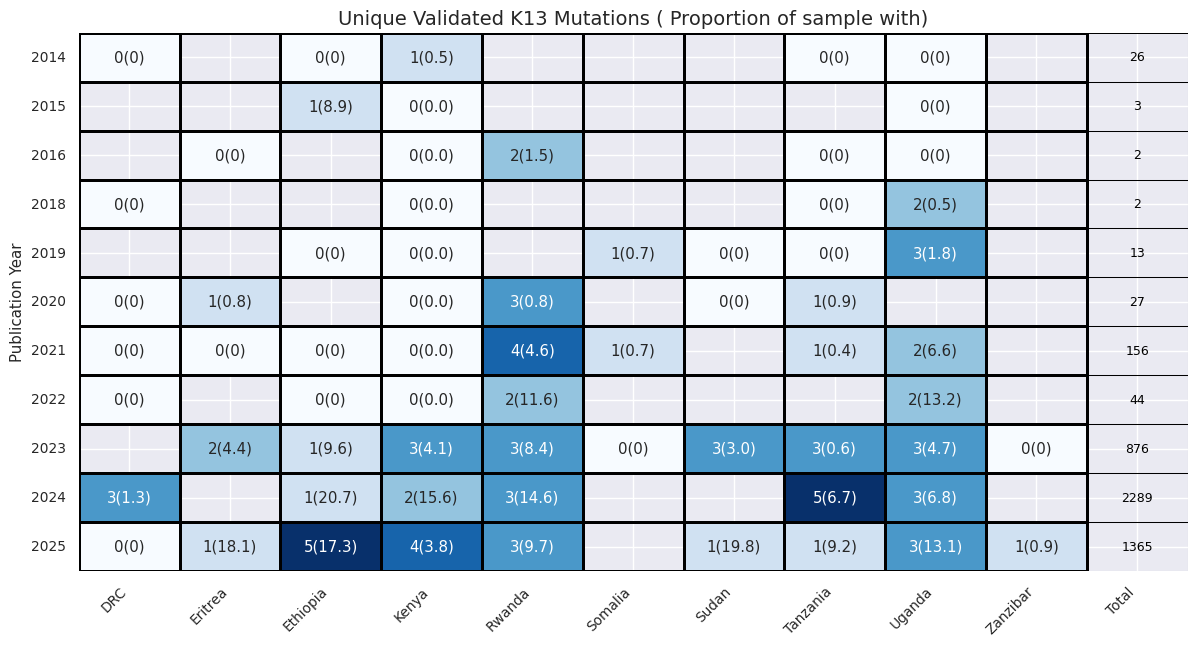

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))
sns.set(font_scale=0.9)

# --- 1. Prepare heatmap data (exclude Total) ---
heatmap_values = validated_counts.replace('-', np.nan).astype(float)

heatmap_values_no_total = heatmap_values.drop(columns=["Total"], errors="ignore")
combined_table_no_total = combined_table.drop(columns=["Total"], errors="ignore")

# --- 2. Plot heatmap ---
ax = sns.heatmap(
    heatmap_values_no_total,
    annot=combined_table_no_total,
    fmt="",
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False
)

# --- 3. Add Total column manually ---
total_values = validated_counts["Total"].astype(str)

n_rows = heatmap_values_no_total.shape[0]
n_cols = heatmap_values_no_total.shape[1]

for i in range(n_rows):
    # Add text
    ax.text(
        n_cols + 0.5,
        i + 0.5,
        total_values.iloc[i],
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )
    
    # Draw cell border (to match heatmap grid)
    rect = plt.Rectangle(
        (n_cols, i),
        1,
        1,
        fill=False,
        edgecolor='black',
        linewidth=0.73
    )
    ax.add_patch(rect)

# --- 4. Extend x-axis ticks to include Total ---
xticks = list(ax.get_xticks()) + [n_cols + 0.5]
xticklabels = list(heatmap_values_no_total.columns) + ["Total"]

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right')

# --- 5. Fix axis limits so new column is fully visible ---
ax.set_xlim(0, n_cols + 1)

# --- 6. Titles and formatting ---
plt.title("Unique Validated K13 Mutations ( Proportion of sample with)", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig("../results/final/k13_validated_proportion_table.png", dpi=720, bbox_inches='tight')
plt.show()

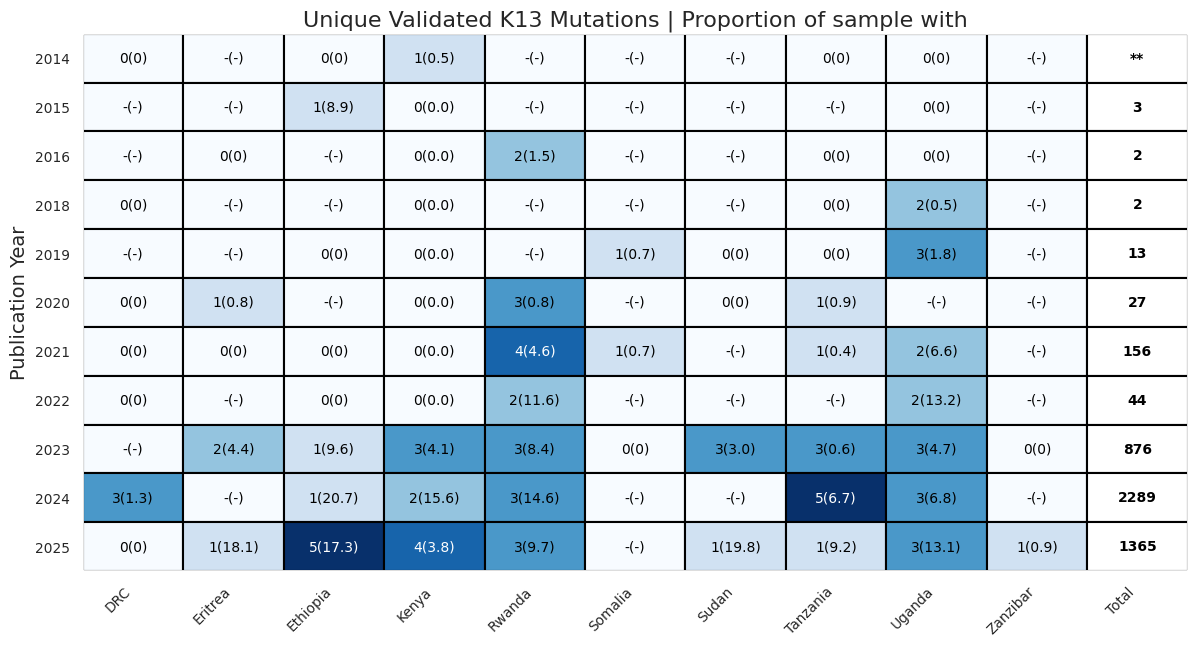

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# validated_counts and combined_table are already defined
all_cols = list(validated_counts.columns)
all_rows = list(validated_counts.index)

n_rows = len(all_rows)
n_cols = len(all_cols)

fig, ax = plt.subplots(figsize=(n_cols * 1.1, n_rows * 0.6))

# --- Numeric values for coloring ---
numeric_counts = validated_counts.drop(columns=["Total"], errors="ignore").apply(pd.to_numeric, errors='coerce')
vmax = numeric_counts.max().max()  # maximum numeric value for scaling colormap

# --- Draw all cells ---
for i, row in enumerate(all_rows):
    for j, col in enumerate(all_cols):
        val = validated_counts.loc[row, col]
        ann = combined_table.loc[row, col]

        # Decide background color
        if col == "Total":
            color = "white"  # Total column white
        else:
            try:
                v = float(val)
                color = plt.cm.Blues(v / vmax) if vmax > 0 else plt.cm.Blues(0)
            except:
                color = plt.cm.Blues(0)

        # Draw rectangle with thicker black border
        rect = plt.Rectangle(
            (j, i),
            1, 1,
            facecolor=color,
            edgecolor='black',
            linewidth=1.5  # thicker border
        )
        ax.add_patch(rect)

        # Text color and style
        if col == "Total":
            text_color = "black"
            fontweight = "bold"  # Total column bold
        else:
            r, g, b, _ = color
            brightness = 0.299*r + 0.587*g + 0.114*b
            text_color = "white" if brightness < 0.5 else "black"
            fontweight = "normal"

        # Add annotation
        ax.text(
            j + 0.5,
            i + 0.5,
            ann,
            ha='center',
            va='center',
            fontsize=10,
            color=text_color,
            fontweight=fontweight
        )

# --- Axes and labels ---
ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)
ax.set_xticks([x + 0.5 for x in range(n_cols)])
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticks([y + 0.5 for y in range(n_rows)])
ax.set_yticklabels(all_rows, rotation=0)
ax.set_title("Unique Validated K13 Mutations | Proportion of sample with", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Publication Year", fontsize=14)

plt.tight_layout()
#plt.savefig("../results/final/k13_validated_proportion_table1.png", dpi=720, bbox_inches='tight')
plt.show()

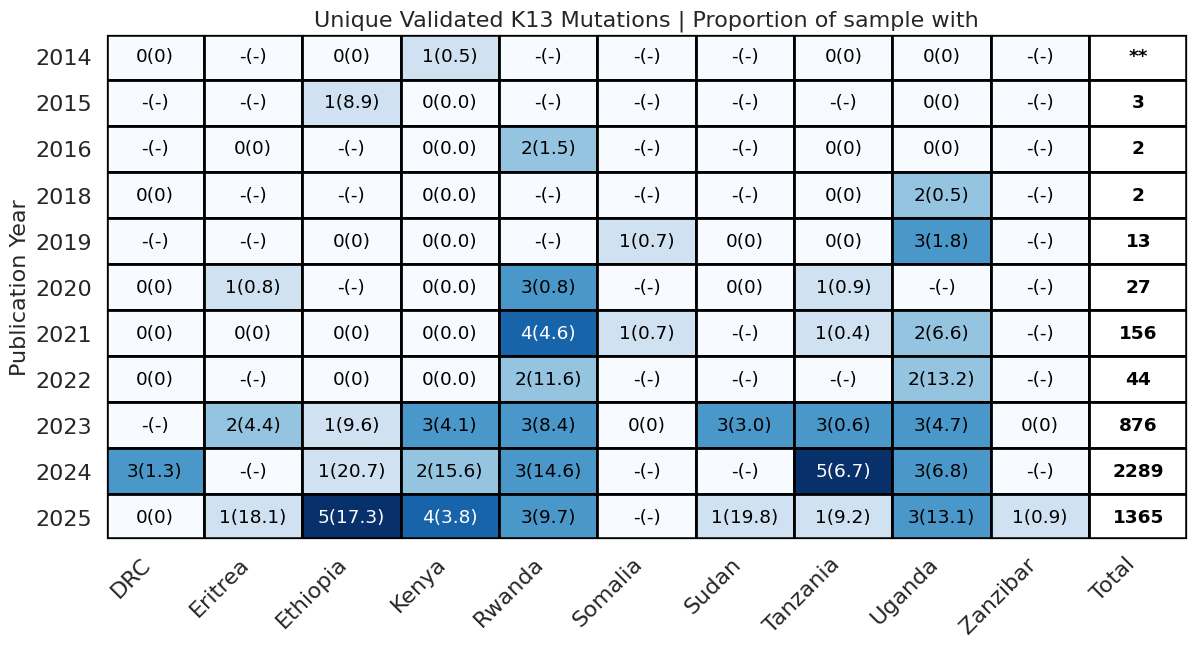

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# validated_counts and combined_table are already defined
all_cols = list(validated_counts.columns)
all_rows = list(validated_counts.index)

n_rows = len(all_rows)
n_cols = len(all_cols)

fig, ax = plt.subplots(figsize=(n_cols * 1.1, n_rows * 0.6))

# --- Numeric values for coloring ---
numeric_counts = validated_counts.drop(columns=["Total"], errors="ignore").apply(pd.to_numeric, errors='coerce')
vmax = numeric_counts.max().max()  # max numeric value for scaling colormap

# --- Draw all cells ---
for i, row in enumerate(all_rows):
    for j, col in enumerate(all_cols):
        val = validated_counts.loc[row, col]
        ann = combined_table.loc[row, col]

        # Decide background color
        if col == "Total":
            color = "white"  # Total column white
        else:
            try:
                v = float(val)
                color = plt.cm.Blues(v / vmax) if vmax > 0 else plt.cm.Blues(0)
            except:
                color = plt.cm.Blues(0)

        # Draw rectangle with bold black borders
        rect = plt.Rectangle(
            (j, i),
            1, 1,
            facecolor=color,
            edgecolor='black',
            linewidth=2  # bold border
        )
        ax.add_patch(rect)

        # Text color and style
        if col == "Total":
            text_color = "black"
            fontweight = "bold"
        else:
            r, g, b, _ = color
            brightness = 0.299*r + 0.587*g + 0.114*b
            text_color = "white" if brightness < 0.5 else "black"
            fontweight = "normal"

        # Add annotation
        ax.text(
            j + 0.5,
            i + 0.5,
            ann,
            ha='center',
            va='center',
            fontsize=13.3,
            color=text_color,
            fontweight=fontweight
        )

# --- Explicitly draw outer borders over everything ---
ax.plot([0, n_cols], [0, 0], color='black', linewidth=4)      # top
ax.plot([0, n_cols], [n_rows, n_rows], color='black', linewidth=4)  # bottom
ax.plot([0, 0], [0, n_rows], color='black', linewidth=4)      # left
ax.plot([n_cols, n_cols], [0, n_rows], color='black', linewidth=4)  # right

# --- Axes and labels ---
ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)
ax.set_xticks([x + 0.5 for x in range(n_cols)])
ax.set_xticklabels(all_cols, rotation=45, ha='right', fontsize=16)
ax.set_yticks([y + 0.5 for y in range(n_rows)])
ax.set_yticklabels(all_rows, rotation=0, fontsize=16)
ax.set_title("Unique Validated K13 Mutations | Proportion of sample with", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Publication Year", fontsize=16)

plt.tight_layout()
#plt.savefig("../results/final/k13_validated_proportion_table1.png", dpi=720, bbox_inches='tight')
plt.show()

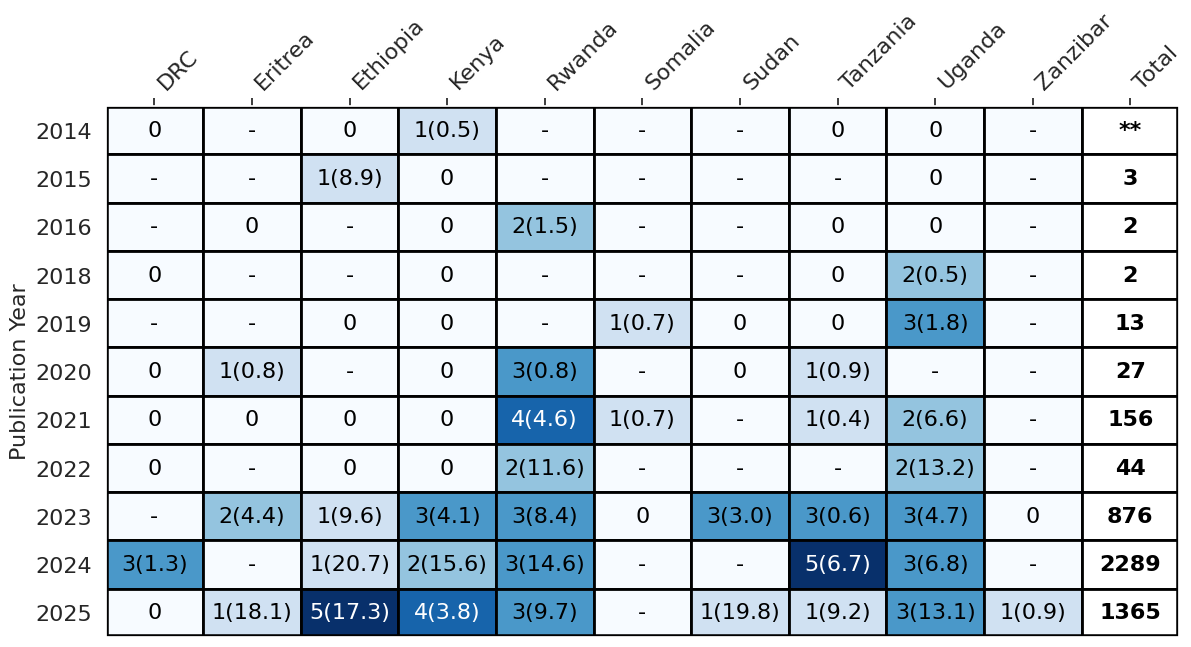

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

# validated_counts and combined_table are already defined
all_cols = list(validated_counts.columns)
all_rows = list(validated_counts.index)

n_rows = len(all_rows)
n_cols = len(all_cols)

fig, ax = plt.subplots(figsize=(n_cols * 1.1, n_rows * 0.6))

# --- Numeric values for coloring ---
numeric_counts = validated_counts.drop(columns=["Total"], errors="ignore").apply(pd.to_numeric, errors='coerce')
vmax = numeric_counts.max().max()  # max value for colormap scaling

# --- Draw all cells ---
for i, row in enumerate(all_rows):
    for j, col in enumerate(all_cols):
        val = validated_counts.loc[row, col]

        # --- annotation ---
        ann = str(combined_table.loc[row, col])

        # --- cleaning rules ---
        replacements = {
            r"-\s*\(\s*-\s*\)": "-",        # -(-) -> -
            r"0\s*\(\s*0\s*\)": "0",        # 0(0) -> 0
            r"0\s*\(\s*0\.0\s*\)": "0",      # 0(0.0) -> 0
        }

        for pattern, repl in replacements.items():
            ann = re.sub(pattern, repl, ann)

        # Decide background color
        if col == "Total":
            color = "white"
        else:
            try:
                v = float(val)
                color = plt.cm.Blues(v / vmax) if vmax > 0 else plt.cm.Blues(0)
            except:
                color = plt.cm.Blues(0)

        # Draw rectangle
        rect = plt.Rectangle(
            (j, i),
            1, 1,
            facecolor=color,
            edgecolor='black',
            linewidth=2
        )
        ax.add_patch(rect)

        # Text color
        if col == "Total":
            text_color = "black"
            fontweight = "bold"
        else:
            r, g, b, _ = color
            brightness = 0.299*r + 0.587*g + 0.114*b
            text_color = "white" if brightness < 0.5 else "black"
            fontweight = "normal"

        # Add annotation
        ax.text(
            j + 0.5,
            i + 0.5,
            ann,
            ha='center',
            va='center',
            fontsize=16,
            color=text_color,
            fontweight=fontweight
        )

# --- Explicit outer border ---
ax.plot([0, n_cols], [0, 0], color='black', linewidth=4)
ax.plot([0, n_cols], [n_rows, n_rows], color='black', linewidth=4)
ax.plot([0, 0], [0, n_rows], color='black', linewidth=4)
ax.plot([n_cols, n_cols], [0, n_rows], color='black', linewidth=4)

# --- Axes formatting ---

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)

# X-axis (countries) on TOP
ax.set_xticks([x + 0.5 for x in range(n_cols)])
ax.set_xticklabels(all_cols, rotation=45, ha='left', fontsize=16)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(top=True, bottom=False)

# Y-axis (years)
ax.set_yticks([y + 0.5 for y in range(n_rows)])
ax.set_yticklabels(all_rows, rotation=0, fontsize=16)

# Titles and labels
ax.set_title("", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Publication Year", fontsize=16)

plt.tight_layout()
plt.savefig("../results/final/k13_validated_proportion_table1.png", dpi=720, bbox_inches='tight')
plt.show()

In [73]:
"""import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Example: validated_counts and combined_table are defined

plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))
sns.set(font_scale=0.9)

# Convert to numeric and replace NaN with 0 for coloring
heatmap_values = validated_counts.apply(pd.to_numeric, errors='coerce').fillna(0)

# Create heatmap
ax = sns.heatmap(
    heatmap_values,
    annot=False,      # we annotate manually
    fmt="",
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False
)

# Get facecolors of the heatmap cells
facecolors = ax.collections[0].get_facecolors()

# Loop over each cell and add annotation
for i, r in enumerate(combined_table.index):
    for j, c in enumerate(combined_table.columns):
        val = combined_table.loc[r, c]
        display_val = val if val not in [None, '', '-'] else '-|-'

        # Get the RGBA of the cell: Matplotlib stores as flat array
        cell_index = i * len(combined_table.columns) + j
        rgba = facecolors[cell_index]
        # Simple brightness threshold: if dark, use white text; else black
        brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        text_color = "white" if brightness < 0.5 else "black"

        ax.text(
            j + 0.5, i + 0.5, display_val,
            ha='center', va='center',
            fontsize=11,
            color=text_color
        )

plt.title("Unique Validated K13 Mutations | Proportion of sample with", fontsize=16)
plt.xlabel("")
plt.ylabel("Publication Year", fontsize=16)
plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.tight_layout()
plt.savefig("../results/final/k13_validated_proportion_table.png", dpi=720, bbox_inches='tight')
plt.show()"""

'import matplotlib.pyplot as plt\nimport seaborn as sns\nimport numpy as np\nimport pandas as pd\n\n# Example: validated_counts and combined_table are defined\n\nplt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))\nsns.set(font_scale=0.9)\n\n# Convert to numeric and replace NaN with 0 for coloring\nheatmap_values = validated_counts.apply(pd.to_numeric, errors=\'coerce\').fillna(0)\n\n# Create heatmap\nax = sns.heatmap(\n    heatmap_values,\n    annot=False,      # we annotate manually\n    fmt="",\n    cmap="Blues",\n    linewidths=0.73,\n    linecolor="black",\n    cbar=False\n)\n\n# Get facecolors of the heatmap cells\nfacecolors = ax.collections[0].get_facecolors()\n\n# Loop over each cell and add annotation\nfor i, r in enumerate(combined_table.index):\n    for j, c in enumerate(combined_table.columns):\n        val = combined_table.loc[r, c]\n        display_val = val if val not in [None, \'\', \'-\'] else \'-|-\'\n\n        # Get the RGBA of the cell: Matplotlib 

In [74]:
#val_df_important= val_df[['pmid', 'year_pub', 'year_sample', 'country','sample_size','samples_genotyped','k13_validated_mutations',"mutation_frequency_(%)",'raw_count','percentage_frequency']]

In [75]:
validated_counts

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,0,-,0,1,-,-,-,0,0,-,26
2015,-,-,1,0,-,-,-,-,0,-,3
2016,-,0,-,0,2,-,-,0,0,-,2
2018,0,-,-,0,-,-,-,0,2,-,2
2019,-,-,0,0,-,1,0,0,3,-,13
2020,0,1,-,0,3,-,0,1,-,-,27
2021,0,0,0,0,4,1,-,1,2,-,156
2022,0,-,0,0,2,-,-,-,2,-,44
2023,-,2,1,3,3,0,3,3,3,0,876


In [76]:
'''import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Figure setup (match example logic) ---
plt.figure(
    figsize=(
        len(combined_table.columns) * 2.2,
        len(combined_table.index) * 1.6
    )
)
sns.set(font_scale=0.9)

# --- Ensure numeric values for heatmap coloring ---
heatmap_values = (
    validated_counts
    .apply(pd.to_numeric, errors="coerce")
    .reindex(index=combined_table.index, columns=combined_table.columns)
    .fillna(0)
)

# --- Heatmap ---
ax = sns.heatmap(
    heatmap_values,
    annot=False,            # manual annotations
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False
)

# Get facecolors for brightness-based text color
facecolors = ax.collections[0].get_facecolors()

# --- Manual annotations (with contrast-aware text color) ---
for i, r in enumerate(combined_table.index):
    for j, c in enumerate(combined_table.columns):
        val = combined_table.loc[r, c]
        display_val = val if val not in [None, "", "-"] else "-|-"

        cell_index = i * len(combined_table.columns) + j
        rgba = facecolors[cell_index]

        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if brightness < 0.5 else "black"

        ax.text(
            j + 0.5,
            i + 0.5,
            display_val,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

# --- Labels & styling (match example) ---
plt.title(
    "Unique Validated K13 Mutations | Proportion of Samples",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Publication Year", fontsize=14, fontweight="bold")

plt.xticks(
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=16,
    fontweight="bold"
)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(
    "../results/final/k13_validated_proportion_table.png",
    dpi=720,
    bbox_inches="tight"
)
plt.show()
'''

'import matplotlib.pyplot as plt\nimport seaborn as sns\nimport pandas as pd\n\n# --- Figure setup (match example logic) ---\nplt.figure(\n    figsize=(\n        len(combined_table.columns) * 2.2,\n        len(combined_table.index) * 1.6\n    )\n)\nsns.set(font_scale=0.9)\n\n# --- Ensure numeric values for heatmap coloring ---\nheatmap_values = (\n    validated_counts\n    .apply(pd.to_numeric, errors="coerce")\n    .reindex(index=combined_table.index, columns=combined_table.columns)\n    .fillna(0)\n)\n\n# --- Heatmap ---\nax = sns.heatmap(\n    heatmap_values,\n    annot=False,            # manual annotations\n    cmap="Blues",\n    linewidths=0.73,\n    linecolor="black",\n    cbar=False\n)\n\n# Get facecolors for brightness-based text color\nfacecolors = ax.collections[0].get_facecolors()\n\n# --- Manual annotations (with contrast-aware text color) ---\nfor i, r in enumerate(combined_table.index):\n    for j, c in enumerate(combined_table.columns):\n        val = combined_table.loc

In [77]:
val_df["year_sample"].isna().sum()


np.int64(4)

In [78]:
'''final_table = (
    val_df
    .assign(raw_count=lambda d: pd.to_numeric(d["raw_count"], errors="coerce").fillna(0))
    .groupby(["year_sample", "country"], as_index=False)
    .agg(
        mutations=(
            "k13_validated_mutations",
            lambda x: ", ".join(sorted(x.dropna().unique()))
        ),
        total_raw_counts=("raw_count", "sum")
    )
    .assign(
        value=lambda d: d["mutations"] + " | " + d["total_raw_counts"].astype(int).astype(str)
    )
    .pivot(index="year_sample", columns="country", values="value")
    .fillna("- | -")
)

final_table'''

'final_table = (\n    val_df\n    .assign(raw_count=lambda d: pd.to_numeric(d["raw_count"], errors="coerce").fillna(0))\n    .groupby(["year_sample", "country"], as_index=False)\n    .agg(\n        mutations=(\n            "k13_validated_mutations",\n            lambda x: ", ".join(sorted(x.dropna().unique()))\n        ),\n        total_raw_counts=("raw_count", "sum")\n    )\n    .assign(\n        value=lambda d: d["mutations"] + " | " + d["total_raw_counts"].astype(int).astype(str)\n    )\n    .pivot(index="year_sample", columns="country", values="value")\n    .fillna("- | -")\n)\n\nfinal_table'

In [79]:
'''import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Helper: wrap mutation text
# -----------------------------
def wrap_value(val, max_per_line=2):
    if val == "- | -":
        return val

    muts, count = val.split(" | ")
    muts = muts.split(", ")

    lines = [
        ", ".join(muts[i:i + max_per_line])
        for i in range(0, len(muts), max_per_line)
    ]
    lines[-1] += f" | {count}"

    return "\n".join(lines)


# -----------------------------
# Build label + count tables
# -----------------------------
label_table = final_table.applymap(
    lambda x: wrap_value(x, max_per_line=2)
)

count_table = final_table.applymap(
    lambda x: int(x.split(" | ")[1]) if x != "- | -" else 0
)


# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(
    figsize=(len(label_table.columns) * 2.2,
             len(label_table.index) * 1.6)
)

sns.set(font_scale=0.9)

ax = sns.heatmap(
    count_table,
    annot=False,
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False
)

facecolors = ax.collections[0].get_facecolors()

# -----------------------------
# Manual annotations
# -----------------------------
for i, year in enumerate(label_table.index):
    for j, country in enumerate(label_table.columns):

        val = label_table.loc[year, country]
        cell_index = i * len(label_table.columns) + j
        rgba = facecolors[cell_index]

        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if brightness < 0.5 else "black"

        ax.text(
            j + 0.5,
            i + 0.5,
            val,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

# -----------------------------
# Formatting & save
# -----------------------------
plt.title(
    "Validated K13 Mutations | Total Raw Counts",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Publication Year", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=16, fontweight="bold")
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig("./final_table_raw1.png", dpi=720, bbox_inches="tight")
plt.show()
'''

'import matplotlib.pyplot as plt\nimport seaborn as sns\nimport pandas as pd\n\n# -----------------------------\n# Helper: wrap mutation text\n# -----------------------------\ndef wrap_value(val, max_per_line=2):\n    if val == "- | -":\n        return val\n\n    muts, count = val.split(" | ")\n    muts = muts.split(", ")\n\n    lines = [\n        ", ".join(muts[i:i + max_per_line])\n        for i in range(0, len(muts), max_per_line)\n    ]\n    lines[-1] += f" | {count}"\n\n    return "\n".join(lines)\n\n\n# -----------------------------\n# Build label + count tables\n# -----------------------------\nlabel_table = final_table.applymap(\n    lambda x: wrap_value(x, max_per_line=2)\n)\n\ncount_table = final_table.applymap(\n    lambda x: int(x.split(" | ")[1]) if x != "- | -" else 0\n)\n\n\n# -----------------------------\n# Plot heatmap\n# -----------------------------\nplt.figure(\n    figsize=(len(label_table.columns) * 2.2,\n             len(label_table.index) * 1.6)\n)\n\nsns.set(f

In [80]:
validated_counts

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Uganda,Zanzibar,Total
year_pub,,,,,,,,,,,
2014,0,-,0,1,-,-,-,0,0,-,26
2015,-,-,1,0,-,-,-,-,0,-,3
2016,-,0,-,0,2,-,-,0,0,-,2
2018,0,-,-,0,-,-,-,0,2,-,2
2019,-,-,0,0,-,1,0,0,3,-,13
2020,0,1,-,0,3,-,0,1,-,-,27
2021,0,0,0,0,4,1,-,1,2,-,156
2022,0,-,0,0,2,-,-,-,2,-,44
2023,-,2,1,3,3,0,3,3,3,0,876


In [81]:
proportion_table

country,DRC,Eritrea,Ethiopia,Kenya,Rwanda,Somalia,Sudan,Tanzania,Total,Uganda,Zanzibar
year_pub,,,,,,,,,,,
2014,0,-,0,0.5,-,-,-,0,,0,-
2015,-,-,8.9,0.0,-,-,-,-,,0,-
2016,-,0,-,0.0,1.5,-,-,0,,0,-
2018,0,-,-,0.0,-,-,-,0,,0.5,-
2019,-,-,0,0.0,-,0.7,0,0,,1.8,-
2020,0,0.8,-,0.0,0.8,-,0,0.9,,-,-
2021,0,0,0,0.0,4.6,0.7,-,0.4,,6.6,-
2022,0,-,0,0.0,11.6,-,-,-,,13.2,-
2023,-,4.4,9.6,4.1,8.4,0,3.0,0.6,,4.7,0
